In [ ]:
import pandas as pd
import numpy as numpy
import sklearn
import os
import joblib
import pickle
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df  = pd.read_csv('creditcard.csv')
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51586,45023,-2.943382,-2.332451,2.568959,0.747114,2.083550,-1.319267,-1.837967,0.421285,0.347715,...,-0.013848,-0.091317,-0.268974,0.069693,0.202920,0.356930,-0.006093,0.268288,26.24,0.0
51587,45024,-1.278283,-3.726046,-0.902718,2.796542,-1.750987,0.199763,1.223412,-0.106145,0.793279,...,0.664178,-0.592258,-1.141974,0.322687,0.081328,-0.354449,-0.150956,0.269036,1233.16,0.0
51588,45024,-0.852261,0.886192,-0.378032,-1.142044,1.880941,3.505875,-0.403582,1.365218,-0.369193,...,0.091829,0.066337,-0.055970,1.027545,-0.327900,0.255778,0.132317,0.133329,28.98,0.0
51589,45024,-0.447740,0.775759,1.586053,0.227702,-0.270962,-0.539013,0.488655,0.071070,0.308739,...,-0.033903,0.202157,-0.180777,0.424592,-0.172455,0.365861,0.353120,0.198239,3.99,0.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51591 entries, 0 to 51590
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    51591 non-null  int64  
 1   V1      51591 non-null  float64
 2   V2      51591 non-null  float64
 3   V3      51591 non-null  float64
 4   V4      51591 non-null  float64
 5   V5      51591 non-null  float64
 6   V6      51591 non-null  float64
 7   V7      51591 non-null  float64
 8   V8      51591 non-null  float64
 9   V9      51591 non-null  float64
 10  V10     51591 non-null  float64
 11  V11     51590 non-null  float64
 12  V12     51590 non-null  float64
 13  V13     51590 non-null  float64
 14  V14     51590 non-null  float64
 15  V15     51590 non-null  float64
 16  V16     51590 non-null  float64
 17  V17     51590 non-null  float64
 18  V18     51590 non-null  float64
 19  V19     51590 non-null  float64
 20  V20     51590 non-null  float64
 21  V21     51590 non-null  float64
 22

In [ ]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,51591.000000,51591.000000,51591.000000,51591.000000,51591.000000,51591.000000,51591.000000,51591.000000,51591.000000,51591.000000,...,51590.000000,51590.000000,51590.000000,51590.000000,51590.000000,51590.000000,51590.000000,51590.000000,51590.000000,51590.000000
mean,29408.888120,-0.244221,0.003887,0.691974,0.183611,-0.259039,0.104715,-0.120474,0.054468,0.108449,...,-0.028862,-0.106634,-0.039418,0.007995,0.135556,0.020305,0.004140,0.003987,94.014363,0.002908
std,13196.047307,1.887998,1.641193,1.498371,1.398830,1.413486,1.312673,1.278442,1.216566,1.208872,...,0.732046,0.636907,0.592622,0.595768,0.438858,0.500884,0.389621,0.332373,253.518524,0.053844
min,0.000000,-56.407510,-72.715728,-32.965346,-5.172595,-42.147898,-26.160506,-26.548144,-41.484823,-9.283925,...,-20.262054,-8.593642,-26.751119,-2.836627,-7.495741,-1.577118,-8.567638,-9.617915,0.000000,0.000000
25%,22655.500000,-0.993823,-0.570329,0.215237,-0.723584,-0.871680,-0.634868,-0.606774,-0.146407,-0.622868,...,-0.230767,-0.528352,-0.178719,-0.322127,-0.128074,-0.330665,-0.063502,-0.006740,7.680000,0.000000
50%,33767.000000,-0.246892,0.075692,0.793662,0.190588,-0.290140,-0.150447,-0.077622,0.059086,-0.000482,...,-0.067054,-0.081866,-0.051550,0.062606,0.174933,-0.072844,0.008875,0.022241,25.345000,0.000000
75%,39498.000000,1.154831,0.731302,1.429386,1.066994,0.282184,0.495847,0.424977,0.333436,0.800723,...,0.108996,0.307826,0.078873,0.401672,0.421984,0.299365,0.083277,0.076230,86.160000,0.000000
max,45026.000000,1.960497,18.183626,4.101716,16.491217,34.801666,22.529298,36.677268,20.007208,10.392889,...,22.614889,5.805795,17.297845,4.014444,5.525093,3.517346,11.135740,33.847808,12910.930000,1.000000


In [ ]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [ ]:
df.duplicated().sum()

np.int64(226)

In [ ]:
df.drop_duplicates()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51586,45023,-2.943382,-2.332451,2.568959,0.747114,2.083550,-1.319267,-1.837967,0.421285,0.347715,...,-0.013848,-0.091317,-0.268974,0.069693,0.202920,0.356930,-0.006093,0.268288,26.24,0.0
51587,45024,-1.278283,-3.726046,-0.902718,2.796542,-1.750987,0.199763,1.223412,-0.106145,0.793279,...,0.664178,-0.592258,-1.141974,0.322687,0.081328,-0.354449,-0.150956,0.269036,1233.16,0.0
51588,45024,-0.852261,0.886192,-0.378032,-1.142044,1.880941,3.505875,-0.403582,1.365218,-0.369193,...,0.091829,0.066337,-0.055970,1.027545,-0.327900,0.255778,0.132317,0.133329,28.98,0.0
51589,45024,-0.447740,0.775759,1.586053,0.227702,-0.270962,-0.539013,0.488655,0.071070,0.308739,...,-0.033903,0.202157,-0.180777,0.424592,-0.172455,0.365861,0.353120,0.198239,3.99,0.0


In [ ]:
df.value_counts()

Time   V1         V2         V3         V4         V5         V6         V7         V8         V9         V10        V11        V12        V13        V14        V15        V16        V17        V18        V19        V20        V21        V22        V23        V24        V25       V26        V27        V28        Amount  Class
43153  -2.086016   2.203265   1.654339   2.941050  -1.683045   0.529728  -1.352162   1.793449  -0.723686   0.600365  -0.982212  -0.551636  -1.337000   0.834403   1.251862   0.033455   1.067978   0.160510   0.213087   0.079002   0.216444   0.567241  -0.035345   0.370201  0.157378   0.440341   0.210230   0.090558  0.76    0.0      9
29150   1.218702   0.177978   0.307746   1.131989  -0.196770  -0.403596   0.065584  -0.094974   0.358942  -0.106009  -1.101184   0.118125  -0.169731   0.130161   0.284551   0.010156  -0.376658  -0.257847   0.126905  -0.113694  -0.236935  -0.605319  -0.059527  -0.167249  0.591082  -0.481346   0.024247   0.022717  22.55   0.0      4
31804  -1.783888   1.245670   2.097173   1.031059  -0.793755   0.566460  -0.403512   0.625924   0.627739  -0.124831  -1.036371  -0.111653  -1.024604  -0.264647   0.194921  -0.813251   0.703947  -0.396750   0.589646  -0.264628  -0.054154  -0.029875  -0.094100   0.056197  0.116731  -0.403204  -1.117816  -0.466715  1.00    0.0      4
1548   -1.559446   1.425546   0.812589  -1.129381   0.507528   0.183507   0.654304   0.088059   0.480018   0.547216   0.066070   1.065234   0.982424  -0.609124  -1.381521   0.189597  -0.901688   0.025998   0.560580   0.451195  -0.283995  -0.413642  -0.234995  -0.789509  0.324851   0.419737   0.329608   0.351346  5.00    0.0      4
24050   0.783460  -0.766538   1.331255   1.812482  -0.929991   1.318111  -0.979965   0.472786   2.619051  -0.585481   1.053027  -1.765809   0.328310   1.034281  -2.276501  -0.441464   0.922500   0.463104  -0.140250  -0.002170   0.027365   0.410787  -0.294227  -0.325263  0.518533  -0.140764   0.042981   0.031839  150.00  0.0      4
                                                                                                                                                                                                                                                                                                                                          ..
28515  -0.168300   0.879467  -0.572700  -0.345212   3.136936   3.264143   0.712733   0.460367  -0.818549   0.204106  -0.190375  -0.424611  -0.164746   0.440764   1.012922  -0.357342  -0.677153   0.315576   0.931582   0.155247   0.044611   0.160078  -0.278971   1.013789  0.025695  -0.328249  -0.147690  -0.070130  1.49    0.0      1
        1.226643   0.101988  -0.087072   0.111524  -0.281992  -1.356027   0.469050  -0.371725  -0.153672  -0.145105  -0.143505   0.320964   0.149313   0.452515   0.776253   0.028739  -0.177867  -1.004746   0.264953   0.019692  -0.355100  -1.153663   0.109793   0.420318  0.197932   0.699218  -0.114861   0.007583  50.40   0.0      1
28516   1.132642   0.337160   0.937185   2.326148  -0.331057   0.196819  -0.360145   0.184082  -0.621987   0.853074   0.722693   0.210141  -0.346240   0.335204   0.136237   1.248006  -1.105711   0.758111  -0.804075  -0.133759   0.169129   0.409255  -0.111507  -0.014710  0.432768   0.101513   0.004705   0.016259  10.62   0.0      1
        1.137418  -0.479095   0.892020   0.171813  -0.930779  -0.065570  -0.521457   0.015105   1.087841  -0.505774  -1.074373   0.925220   1.031459  -0.763262  -0.365446  -0.013149  -0.089049  -0.583685   0.628488   0.114993  -0.221117  -0.454646  -0.043240  -0.011370  0.214130   0.964395  -0.038734   0.021180  65.26   0.0      1
28508   1.192997   0.102210   0.817157   2.382114   0.163449   1.725480  -0.682871   0.407522   0.173229   0.527510  -1.042315   0.955290   1.051538  -0.821760  -2.165861   0.685466  -0.930018   0.631747   0.368413  -0.059857  -0.030198   0.294977  -0.366065  -1.317048  0.850381   0.299455   0.048929   0.001316  0.00    0.0      1
Name: cou

In [ ]:
df['Class'].value_counts()

,count
Class,
0.0,51440
1.0,150


In [ ]:
from imblearn.over_sampling import SMOTE

# Drop rows with NaN values in the 'Class' column before proceeding
df_cleaned = df.dropna(subset=['Class'])

# Separate features (X) and target (y) from the cleaned DataFrame
X = df_cleaned.drop('Class', axis=1)
y = df_cleaned['Class']

print("Before OverSampling, counts of label '1': {}".format(sum(y == 1)))
print("Before OverSampling, counts of label '0': {} \n".format(sum(y == 0)))

# Apply SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print("After OverSampling, counts of label '1': {}".format(sum(y_resampled == 1)))
print("After OverSampling, counts of label '0': {}".format(sum(y_resampled == 0)))

Before OverSampling, counts of label '1': 150
Before OverSampling, counts of label '0': 51440 

After OverSampling, counts of label '1': 51440
After OverSampling, counts of label '0': 51440


In [ ]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# 1. Separate features (X) and target (y)
X = df.drop('Class', axis=1)
y = df['Class']

# 2. Initialize the scaler
sc = StandardScaler()

# 3. Fit and transform all features
# We wrap it in a pd.DataFrame to keep the column names
X_scaled = pd.DataFrame(sc.fit_transform(X), columns=X.columns)

# 4. (Optional) Combine them back into a single dataframe
# We use reset_index(drop=True) to make sure the indices align properly,
# especially if you dropped duplicates earlier!
df_scaled = pd.concat([X_scaled, y.reset_index(drop=True)], axis=1)

# View the scaled dataset
display(df_scaled.head())


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-2.228635,-0.590889,-0.046715,1.230930,0.853968,-0.056090,0.272479,0.281652,0.036357,0.211222,...,0.014419,0.603660,-0.119902,0.098921,-0.015988,-0.418105,0.332168,-0.075337,0.219338,0.0
1,-2.228635,0.760643,0.159802,-0.350714,0.189119,0.225726,-0.142516,0.032595,0.025181,-0.301005,...,-0.268993,-0.835353,0.237432,-0.583859,0.072039,0.210808,-0.033682,0.032306,-0.360231,0.0
2,-2.228559,-0.590120,-0.818955,0.721614,0.140239,-0.172737,1.291868,0.713324,0.158816,-1.342672,...,0.378204,1.379042,1.601087,-1.170392,-1.055471,-0.318244,-0.152695,-0.191770,1.122791,0.0
3,-2.228559,-0.382446,-0.115230,0.734818,-0.748420,0.175971,0.870361,0.280096,0.265477,-1.237093,...,-0.108517,0.175707,-0.254638,-1.986647,1.166265,-0.483618,0.150360,0.172913,0.116307,0.0
4,-2.228483,-0.484122,0.532453,0.571789,0.156863,-0.104816,-0.006699,0.558040,-0.267149,0.586743,...,0.026544,1.420806,-0.165436,0.223700,-0.778313,0.962281,0.552548,0.635337,-0.094765,0.0


In [ ]:
import pandas as pd
import numpy as np

# 1. Separate features (everything except 'Class')
features = df_scaled.drop('Class', axis=1)

# 2. Calculate Skewness and Kurtosis
skewness = features.skew()
kurtosis = features.kurtosis()

# 3. Calculate Outliers using the IQR (Interquartile Range) Method
outlier_counts = {}

for col in features.columns:
    Q1 = features[col].quantile(0.25)
    Q3 = features[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Count how many values fall outside the lower and upper bounds
    outliers = ((features[col] < lower_bound) | (features[col] > upper_bound)).sum()
    outlier_counts[col] = outliers

# 4. Combine results into a clean summary DataFrame
summary_df = pd.DataFrame({
    'Skewness': skewness,
    'Kurtosis': kurtosis,
    'Outlier Count (IQR)': pd.Series(outlier_counts)
})

# Display the summary table
display(summary_df)


,Skewness,Kurtosis,Outlier Count (IQR)
Time,-0.941076,-0.367714,0
V1,-4.408523,50.794779,1395
V2,-4.710806,132.888593,2792
V3,-6.418442,89.082065,1763
V4,0.477475,2.899002,609
V5,-1.416303,75.549220,3151
V6,0.981261,16.347643,4366
V7,-2.014812,92.812222,1818
V8,-5.682197,154.135297,4791
V9,0.498264,3.216268,1294


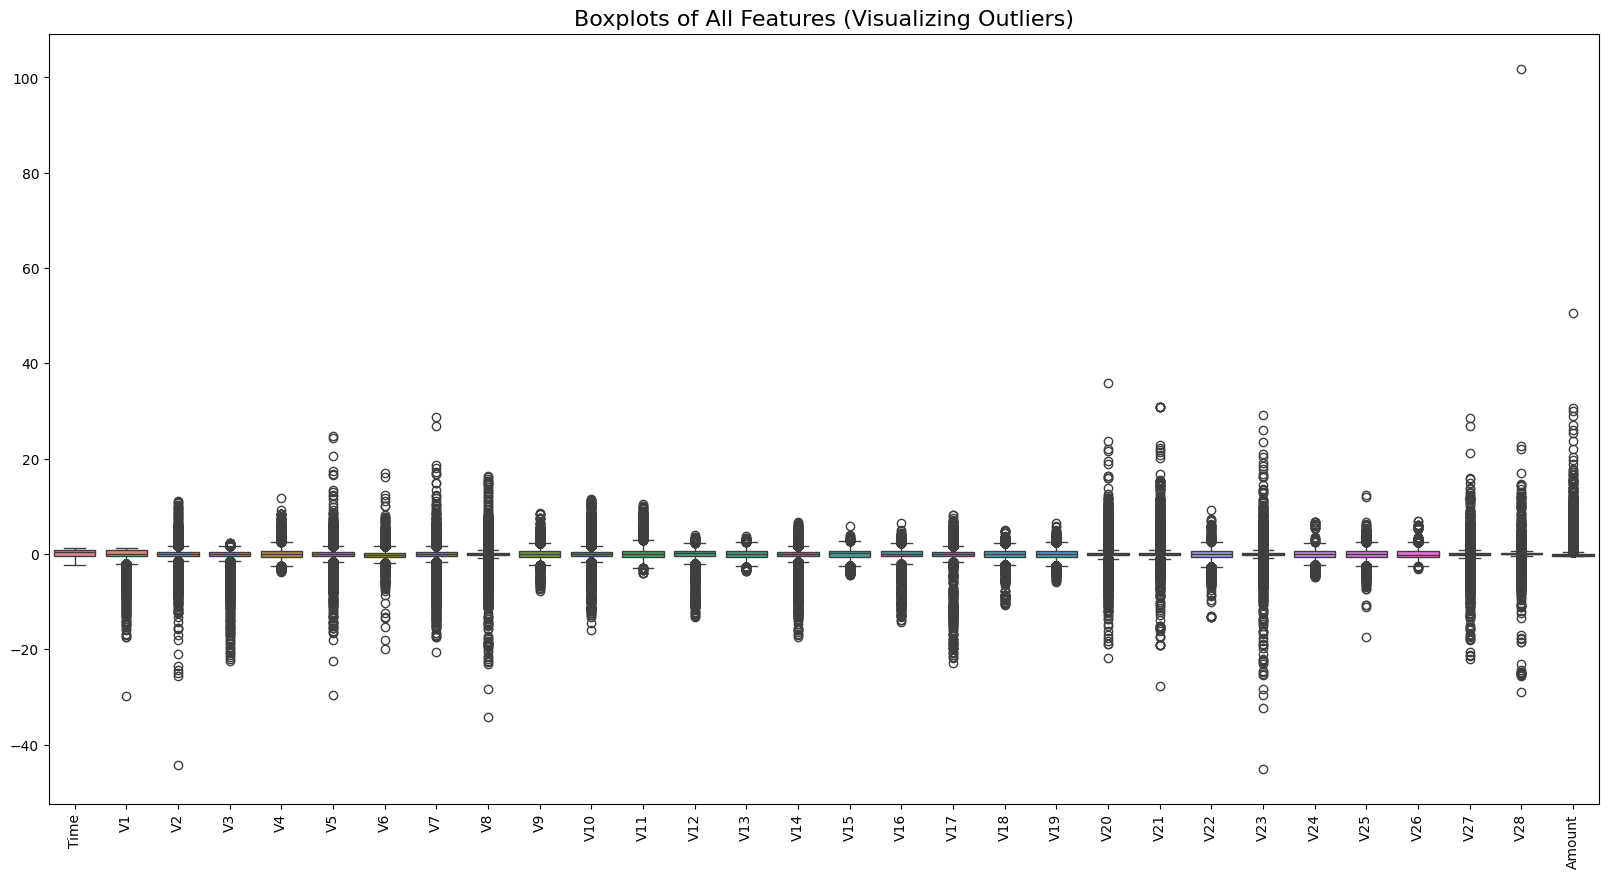

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(20, 10))

# Plot boxplots for all features
sns.boxplot(data=features)

plt.xticks(rotation=90)
plt.title("Boxplots of All Features (Visualizing Outliers)", fontsize=16)
plt.show()


In [ ]:
from sklearn.preprocessing import RobustScaler
import pandas as pd

X = df_scaled.drop('Class', axis=1)
y = df['Class']

# Initialize RobustScaler
rs = RobustScaler()

# Transform all features
X_robust = pd.DataFrame(rs.fit_transform(X), columns=X.columns)

# Re-combine
df_robust = pd.concat([X_robust, y.reset_index(drop=True)], axis=1)

display(df_robust.head())
df_robust = df


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-2.004869,-0.517959,-0.114067,1.435313,0.663231,-0.041756,0.541989,0.307458,0.082551,0.255880,...,0.143475,0.430176,-0.228749,0.005972,-0.084344,-0.184548,0.849467,-0.521804,1.583524,0.0
1,-2.004869,0.669605,0.146323,-0.516560,0.143845,0.303466,0.060215,-0.001145,0.054216,-0.179085,...,-0.467152,-0.665894,0.593336,-0.556028,-0.014113,0.315443,-0.121666,-0.090596,-0.288672,0.0
2,-2.004809,-0.517283,-1.087755,0.806777,0.105659,-0.184647,1.725409,0.842338,0.393023,-1.063629,...,0.927270,1.020770,3.730573,-1.038806,-0.913677,-0.105158,-0.437582,-0.988225,4.501975,0.0
3,-2.004809,-0.334805,-0.200455,0.823071,-0.588570,0.242517,1.236076,0.305530,0.663444,-0.973975,...,-0.121397,0.104212,-0.538723,-1.710670,0.858896,-0.236631,0.366865,0.472663,1.250701,0.0
4,-2.004750,-0.424145,0.616184,0.621881,0.118646,-0.101444,0.217887,0.649927,-0.686930,0.574759,...,0.169599,1.052580,-0.333505,0.108679,-0.692551,0.912871,1.434456,2.325093,0.568871,0.0


In [ ]:
# Create a new, balanced dataframe by combining the resampled features and target
df_balanced = pd.concat([pd.DataFrame(X_resampled, columns=X.columns), pd.Series(y_resampled, name='Class')], axis=1)

# Now check the value counts on the NEW dataframe
print(df_balanced['Class'].value_counts())


Class
0.0    51440
1.0    51440
Name: count, dtype: int64


In [ ]:
# The .round(3) makes the numbers much easier to read
display(df_balanced.describe().round(3))


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,102880.000,102880.000,102880.000,102880.000,102880.000,102880.000,102880.000,102880.000,102880.000,102880.000,...,102880.000,102880.000,102880.000,102880.000,102880.000,102880.000,102880.000,102880.000,102880.000,102880.0
mean,28286.447,-4.107,2.865,-5.062,3.115,-3.110,-1.131,-4.284,2.047,-1.797,...,0.459,-0.167,-0.145,-0.042,0.206,0.089,0.309,0.028,86.756,0.5
std,13076.323,7.116,4.199,8.258,3.579,5.394,1.807,6.189,4.416,2.660,...,1.150,0.728,0.964,0.553,0.717,0.431,0.886,0.483,210.281,0.5
min,0.000,-56.408,-72.716,-32.965,-5.173,-42.148,-26.161,-26.548,-41.485,-9.284,...,-20.262,-8.594,-26.751,-2.837,-7.496,-1.577,-8.568,-9.618,0.000,0.0
25%,17930.000,-4.602,0.046,-7.974,0.169,-4.157,-2.460,-6.958,-0.056,-3.649,...,-0.150,-0.565,-0.307,-0.339,-0.165,-0.224,-0.039,-0.022,2.670,0.0
50%,31994.000,-1.174,1.328,-1.058,2.430,-0.909,-0.896,-1.045,0.347,-1.029,...,0.177,-0.099,-0.079,0.039,0.164,0.058,0.095,0.046,24.500,0.5
75%,40562.000,0.601,4.752,0.820,6.107,0.037,-0.062,0.015,1.778,0.099,...,1.231,0.308,0.098,0.355,0.534,0.392,0.708,0.278,99.990,1.0
max,45024.000,1.960,18.184,4.102,16.491,34.802,22.529,36.677,20.007,10.393,...,22.615,5.806,17.298,4.014,5.525,3.517,11.136,33.848,12910.930,1.0


In [ ]:
from sklearn.preprocessing import RobustScaler
from imblearn.over_sampling import SMOTE
import pandas as pd

# 1. Drop the 'Time' column as it's not useful
if 'Time' in df.columns:
    df = df.drop('Time', axis=1)

# Drop rows with NaN values in the 'Class' column before proceeding
df = df.dropna(subset=['Class']).copy() # Added .copy() here

# 2. Standardize 'Amount' using RobustScaler (best for fraud data)
rs = RobustScaler()
df['Amount'] = rs.fit_transform(df[['Amount']])

print("--- Data Standardized Successfully ---")

# 3. Separate features (X) and target (y)
X = df.drop('Class', axis=1)
y = df['Class']

# 4. Apply SMOTE to fix Class Imbalance
smote = SMOTE(random_state=42)
X_balanced, y_balanced = smote.fit_resample(X, y)

print("--- Class Imbalance Fixed with SMOTE ---")

# 5. Bring it all together into a final, clean DataFrame!
df_final = pd.concat([pd.DataFrame(X_balanced, columns=X.columns), pd.Series(y_balanced, name='Class')], axis=1)

# Now let's print the mean of our final dataset to prove it worked
display(df_final.describe().round(3))

--- Data Standardized Successfully ---
--- Class Imbalance Fixed with SMOTE ---


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,102880.000,102880.000,102880.000,102880.000,102880.000,102880.000,102880.000,102880.000,102880.000,102880.000,...,102880.000,102880.000,102880.000,102880.000,102880.000,102880.000,102880.000,102880.000,102880.000,102880.0
mean,-3.860,2.725,-4.743,3.036,-2.936,-1.076,-4.055,1.916,-1.756,-3.778,...,0.452,-0.159,-0.125,-0.036,0.211,0.089,0.306,0.024,0.778,0.5
std,7.055,4.181,8.257,3.618,5.351,1.811,6.231,4.342,2.723,4.926,...,1.177,0.724,0.928,0.559,0.712,0.438,0.906,0.494,2.743,0.5
min,-56.408,-72.716,-32.965,-5.173,-42.148,-26.161,-26.548,-41.485,-9.284,-18.271,...,-20.262,-8.594,-26.751,-2.837,-7.496,-1.577,-8.568,-9.618,-0.323,0.0
25%,-4.299,0.024,-6.841,0.161,-3.563,-2.449,-6.458,-0.067,-3.687,-7.118,...,-0.166,-0.562,-0.296,-0.327,-0.159,-0.225,-0.035,-0.013,-0.297,0.0
50%,-1.034,1.153,-0.663,2.084,-0.896,-0.797,-0.823,0.288,-0.872,-1.178,...,0.154,-0.092,-0.072,0.052,0.157,0.046,0.084,0.048,-0.038,0.5
75%,0.764,4.422,0.867,6.112,0.122,-0.027,0.094,1.538,0.167,-0.076,...,1.213,0.317,0.098,0.364,0.527,0.411,0.608,0.243,0.951,1.0
max,1.960,18.184,4.102,16.491,34.802,22.529,36.677,20.007,10.393,13.198,...,22.615,5.806,17.298,4.014,5.525,3.517,11.136,33.848,164.189,1.0


In [ ]:
from sklearn.preprocessing import PowerTransformer
import pandas as pd

# 1. Separate features and target from your newly balanced data
X = df_final.drop('Class', axis=1)
y = df_final['Class']

# 2. Initialize the Power Transformer (Yeo-Johnson is the best method here)
pt = PowerTransformer(method='yeo-johnson')

# 3. Fit and transform the features
X_transformed = pd.DataFrame(pt.fit_transform(X), columns=X.columns)

# 4. Re-combine with the target variable
df_ready_for_ml = pd.concat([X_transformed, y], axis=1)

print("Skewness and Kurtosis fixed!")
display(df_ready_for_ml.head())


Skewness and Kurtosis fixed!


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-0.113384,-0.626819,2.029216,-0.281024,0.345996,0.857014,0.679082,-0.344715,0.731975,0.751209,...,-0.378542,0.561438,-0.055985,0.084364,-0.124869,-0.599630,-0.222296,-0.107860,1.286565,0.0
1,1.368127,-0.523294,0.377306,-0.597499,0.477586,0.564057,0.565049,-0.349564,0.426261,0.652770,...,-0.560282,-0.716166,0.217289,-0.628629,-0.070618,0.154200,-0.378066,-0.035195,-1.007078,0.0
2,-0.113004,-1.068102,1.365130,-0.623390,0.296716,1.560551,0.911789,-0.292920,-0.076154,0.799501,...,-0.148976,1.391216,1.406473,-1.159620,-0.760224,-0.474150,-0.428238,-0.186191,1.761658,0.0
3,-0.002118,-0.662757,1.380855,-1.199841,0.452795,1.271750,0.678320,-0.249597,-0.029754,0.694208,...,-0.457073,0.145542,-0.154575,-1.815695,0.608671,-0.683080,-0.299990,0.060084,1.154203,0.0
4,-0.058589,-0.350404,1.192434,-0.614533,0.325103,0.660535,0.823373,-0.484594,0.987881,1.052150,...,-0.370823,1.438375,-0.089553,0.229416,-0.591725,0.955855,-0.127410,0.376143,0.707863,0.0


Class distribution:
 Class
0.0    51440
1.0    51440
Name: count, dtype: int64
Training: (82304, 29) | Testing: (20576, 29)

--- 5-Fold Cross-Validation (F1-Score) ---
Logistic Regression: 0.9789 (+/- 0.0008)
Random Forest: 0.9998 (+/- 0.0001)
XGBoost: 0.9998 (+/- 0.0001)

--- Final Test Set Results ---

Logistic Regression:

              precision    recall  f1-score   support

         0.0       0.97      0.99      0.98     10288
         1.0       0.99      0.97      0.98     10288

    accuracy                           0.98     20576
   macro avg       0.98      0.98      0.98     20576
weighted avg       0.98      0.98      0.98     20576



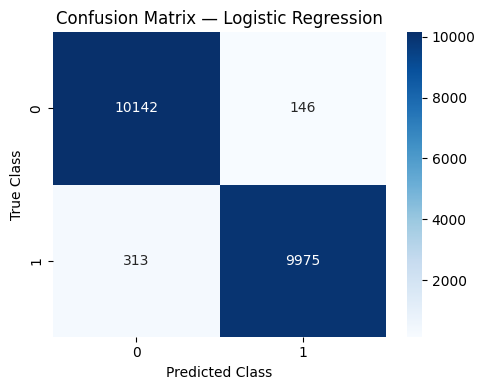


Random Forest:

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     10288
         1.0       1.00      1.00      1.00     10288

    accuracy                           1.00     20576
   macro avg       1.00      1.00      1.00     20576
weighted avg       1.00      1.00      1.00     20576



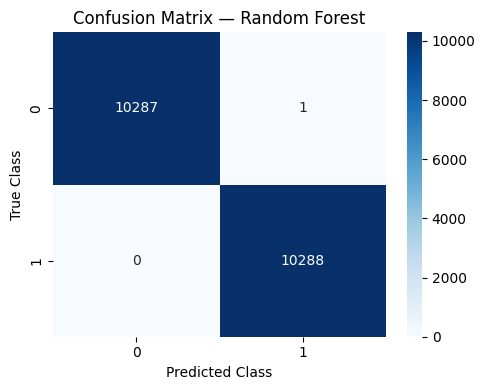


XGBoost:

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     10288
         1.0       1.00      1.00      1.00     10288

    accuracy                           1.00     20576
   macro avg       1.00      1.00      1.00     20576
weighted avg       1.00      1.00      1.00     20576



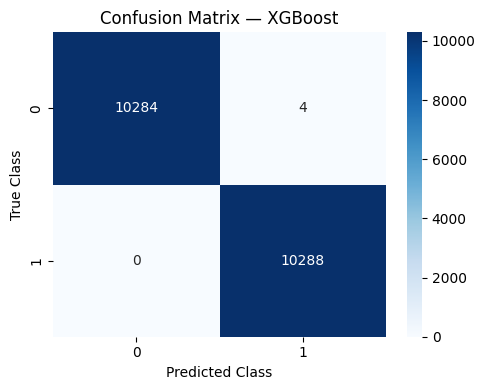

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Sanity check on balance
X = df_final.drop('Class', axis=1)
y = df_final['Class']
print("Class distribution:\n", y.value_counts())

# 2. Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f"Training: {X_train.shape} | Testing: {X_test.shape}\n")

# 3. Models — LR wrapped in pipeline for scaling
models = {
    "Logistic Regression": Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "XGBoost": XGBClassifier(eval_metric='logloss', random_state=42, n_jobs=1, verbosity=0)
}

# 4. Cross-Validation with F1 (correct metric for fraud)
print("--- 5-Fold Cross-Validation (F1-Score) ---")
for name, model in models.items():
    try:
        # Use n_jobs=1 to avoid compatibility issues
        cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='f1', n_jobs=1)
        print(f"{name}: {np.mean(cv_scores):.4f} (+/- {np.std(cv_scores):.4f})")
    except Exception as e:
        print(f"{name}: Error in cross-validation - {str(e)[:100]}")

# 5. Final evaluation on all models
print("\n--- Final Test Set Results ---")
for name, model in models.items():
    try:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        print(f"\n{'='*40}\n{name}:\n")
        print(classification_report(y_test, y_pred))

        # Confusion matrix per model
        plt.figure(figsize=(5, 4))
        sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
        plt.title(f'Confusion Matrix — {name}')
        plt.ylabel('True Class')
        plt.xlabel('Predicted Class')
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"{name}: Error during training/evaluation - {str(e)[:100]}")


Training Isolation Forest on the raw imbalanced data...

--- Unsupervised Isolation Forest Results ---
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     51440
         1.0       0.66      0.39      0.49       150

    accuracy                           1.00     51590
   macro avg       0.83      0.69      0.74     51590
weighted avg       1.00      1.00      1.00     51590



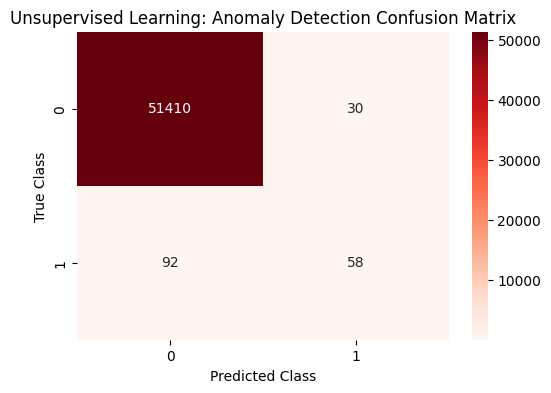

In [ ]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Grab the ORIGINAL, imbalanced dataset
imbalanced = df.drop('Class', axis=1)
y_imbalanced = df['Class']

# 2. Initialize Isolation Forest
# Contamination is set to ~0.17% (the true expected ratio of fraud in the raw dataset)
iso_forest = IsolationForest(n_estimators=100, contamination=0.0017, random_state=42, n_jobs=-1)

# 3. Fit and Predict
print("Training Isolation Forest on the raw imbalanced data...")
y_pred_iso = iso_forest.fit_predict(imbalanced)

# 4. Map the predictions
# Isolation Forest tags anomalies as -1, and normal transactions as 1.
# We flip it to 1 (Fraud) and 0 (Normal) to match our actual data.
y_pred_iso = [1 if x == -1 else 0 for x in y_pred_iso]

# 5. Evaluate the Anomaly Detector
print("\n--- Unsupervised Isolation Forest Results ---")
print(classification_report(y_imbalanced, y_pred_iso))

# Plot Confusion Matrix for Isolation forest
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_imbalanced, y_pred_iso), annot=True, fmt='d', cmap='Reds')
plt.title('Unsupervised Learning: Anomaly Detection Confusion Matrix')
plt.ylabel('True Class')
plt.xlabel('Predicted Class')
plt.show()

 Dataset Summary
Class
Legit    51440
Fraud    51440
Name: count, dtype: int64

Fraud rate: 50.000%

Train: (82304, 29)  |  Test: (20576, 29)


>>> MODEL 1: XGBoost + Random Oversampling
After oversampling → {0.0: 41152, 1.0: 41152}

  XGBoost + RandomOverSampler
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     10288
       Fraud       1.00      1.00      1.00     10288

    accuracy                           1.00     20576
   macro avg       1.00      1.00      1.00     20576
weighted avg       1.00      1.00      1.00     20576

  F1-Score : 0.9998
  AUC-ROC  : 1.0000
  Avg Prec : 1.0000


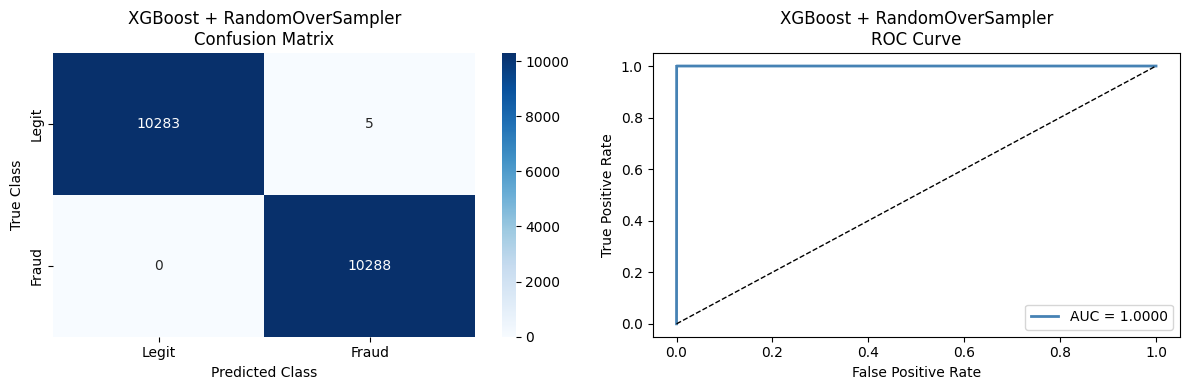



>>> MODEL 2: Random Forest + SMOTE

  Random Forest + SMOTE
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     10288
       Fraud       1.00      1.00      1.00     10288

    accuracy                           1.00     20576
   macro avg       1.00      1.00      1.00     20576
weighted avg       1.00      1.00      1.00     20576

  F1-Score : 0.9999
  AUC-ROC  : 1.0000
  Avg Prec : 1.0000


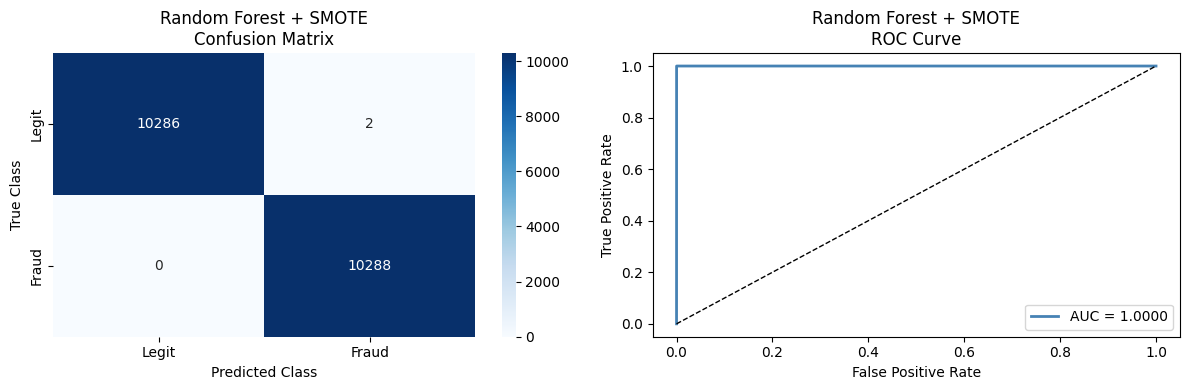

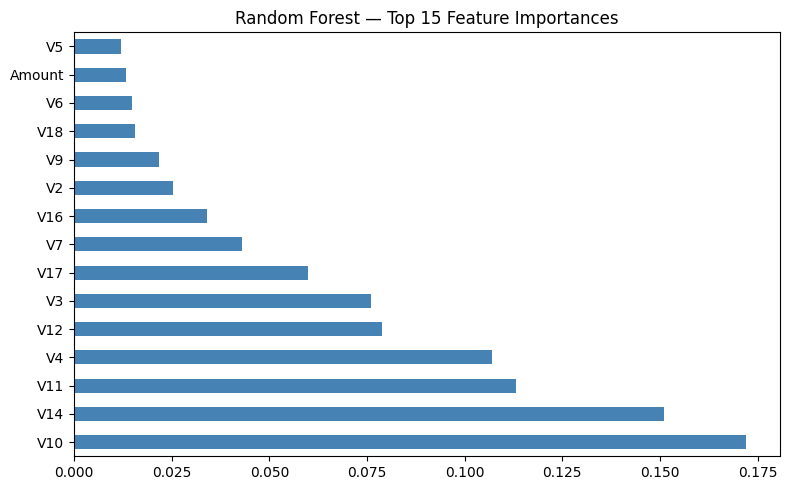



>>> MODEL 3: Stacking Ensemble (RF + XGB + CatBoost + SVM + DT → LR)

  Stacking Ensemble
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     10288
       Fraud       1.00      1.00      1.00     10288

    accuracy                           1.00     20576
   macro avg       1.00      1.00      1.00     20576
weighted avg       1.00      1.00      1.00     20576

  F1-Score : 0.9999
  AUC-ROC  : 1.0000
  Avg Prec : 1.0000


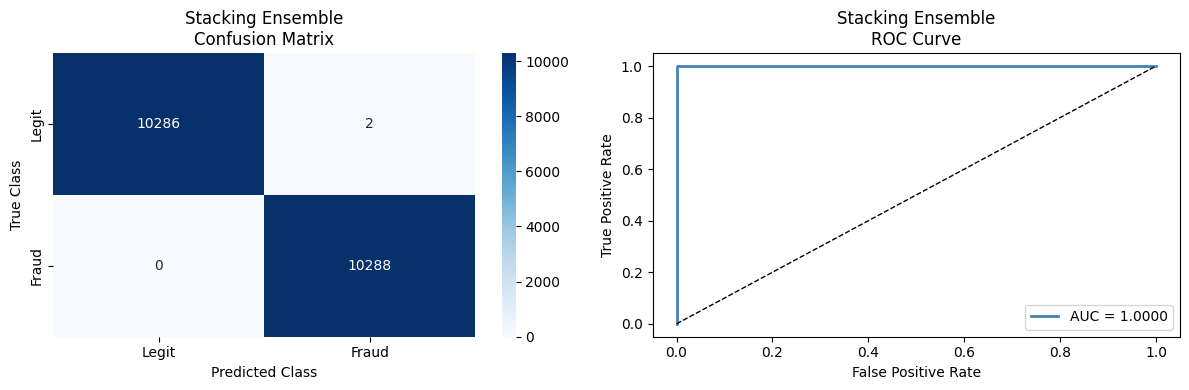



>>> MODEL 4: LSTM (Deep Learning)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 1, 128)         │        80,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 132,673 (518.25 KB)

 Trainable params: 132,545 (517.75 KB)

 Non-trainable params: 128 (512.00 B)

Epoch 1/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.9645 - auc: 0.9929 - loss: 0.1056 - val_accuracy: 0.9850 - val_auc: 0.9990 - val_loss: 0.3289 - learning_rate: 0.0010
Epoch 2/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9876 - auc: 0.9988 - loss: 0.0367 - val_accuracy: 0.9927 - val_auc: 0.9996 - val_loss: 0.1199 - learning_rate: 0.0010
Epoch 3/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9918 - auc: 0.9993 - loss: 0.0240 - val_accuracy: 0.9964 - val_auc: 0.9998 - val_loss: 0.0313 - learning_rate: 0.0010
Epoch 4/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9948 - auc: 0.9996 - loss: 0.0170 - val_accuracy: 0.9974 - val_auc: 0.9997 - val_loss: 0.0116 - learning_rate: 0.0010
Epoch 5/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9962 - auc: 0.9996 - loss: 0.0130 - val_accuracy: 0.9986 - val_auc: 1.0000 - val_loss: 0.0065 - learning_rate: 0.0010
Epoch 6/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9972 - a

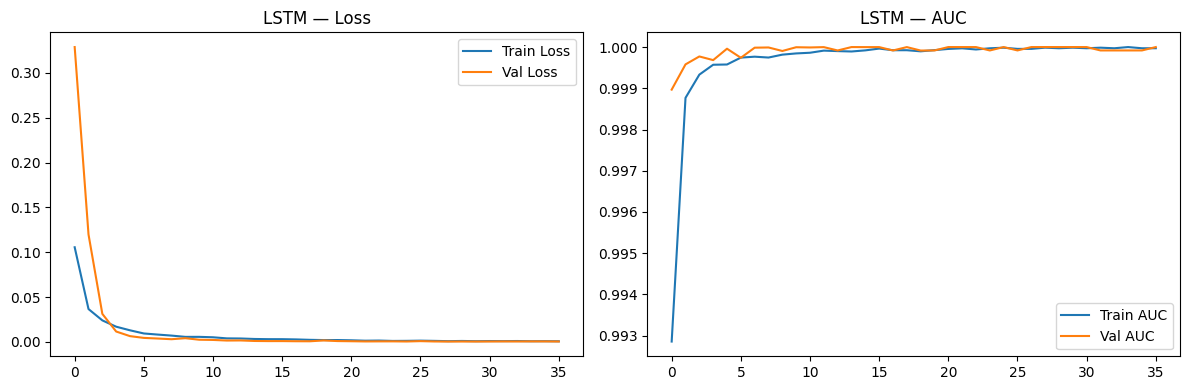

643/643 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step

  LSTM (Deep Learning)
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     10288
       Fraud       1.00      1.00      1.00     10288

    accuracy                           1.00     20576
   macro avg       1.00      1.00      1.00     20576
weighted avg       1.00      1.00      1.00     20576

  F1-Score : 0.9994
  AUC-ROC  : 0.9999
  Avg Prec : 0.9999


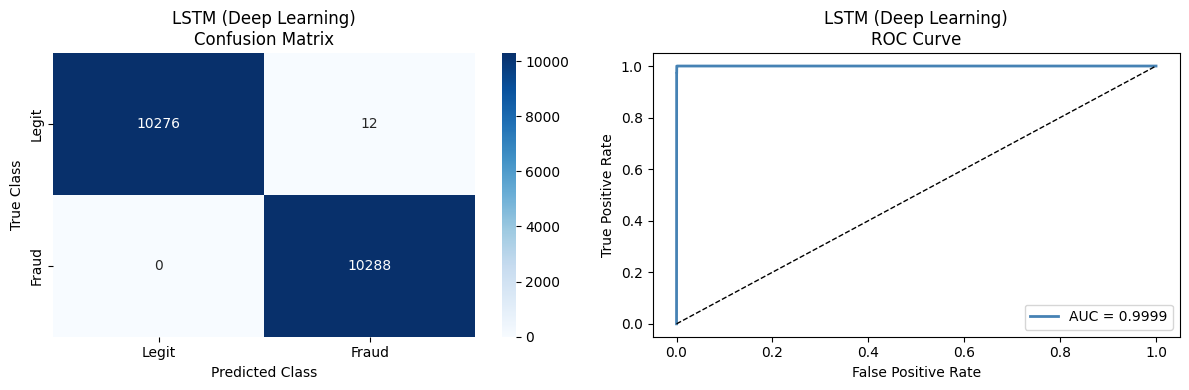



  FINAL MODEL COMPARISON
                      model     f1    auc
      Random Forest + SMOTE 0.9999 1.0000
          Stacking Ensemble 0.9999 1.0000
XGBoost + RandomOverSampler 0.9998 1.0000
       LSTM (Deep Learning) 0.9994 0.9999


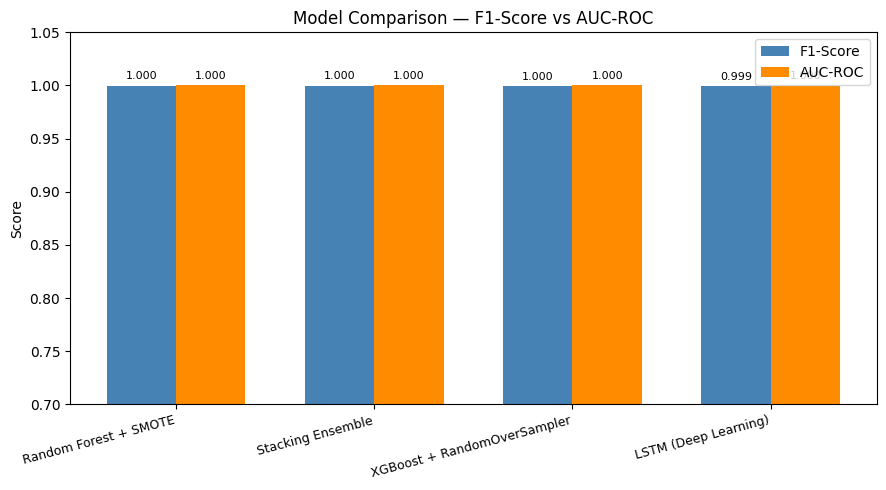


✅ All models trained and evaluated.
   Saved: *_results.png, lstm_training_curves.png, model_comparison.png


In [ ]:
!pip install XGBoost
!pip install CatBoost
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, average_precision_score,
    precision_recall_curve, f1_score
)

# Classical ML
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    StackingClassifier
)
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

# Boosting
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

# Imbalance handling
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.pipeline import Pipeline as ImbPipeline

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    LSTM, Dense, Dropout, Input,
    BatchNormalization, Reshape
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam


# ─────────────────────────────────────────────
#  SECTION 1 — LOAD & PREPARE DATA
# ─────────────────────────────────────────────
# Use the already processed and balanced DataFrame from previous steps
df = df_ready_for_ml

print("=" * 60)
print(" Dataset Summary")
print("=" * 60)
print(df['Class'].value_counts().rename({0: 'Legit', 1: 'Fraud'}))
print(f"\nFraud rate: {df['Class'].mean()*100:.3f}%")

# Features & target
X = df.drop('Class', axis=1)
y = df['Class']

# Scaling of Amount and Time was already handled in previous cells (df_ready_for_ml is already scaled)
# This section is removed as it would be redundant and potentially cause errors if 'Time' column is dropped.

# Train/Test split (stratified to preserve fraud ratio)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"\nTrain: {X_train.shape}  |  Test: {X_test.shape}")


# ─────────────────────────────────────────────
#  HELPER: Evaluation function
# ─────────────────────────────────────────────
def evaluate_model(name, y_true, y_pred, y_prob=None):
    """Print full metrics and plot confusion matrix + ROC curve."""
    print(f"\n{'='*60}")
    print(f"  {name}")
    print(f"{'='*60}")
    print(classification_report(y_true, y_pred, target_names=['Legit', 'Fraud']))

    f1  = f1_score(y_true, y_pred)
    print(f"  F1-Score : {f1:.4f}")

    if y_prob is not None:
        auc  = roc_auc_score(y_true, y_prob)
        ap   = average_precision_score(y_true, y_prob)
        print(f"  AUC-ROC  : {auc:.4f}")
        print(f"  Avg Prec : {ap:.4f}")
    else:
        auc = None

    # ── Confusion Matrix ──
    fig, axes = plt.subplots(1, 2 if auc else 1, figsize=(12 if auc else 5, 4))
    ax_cm = axes[0] if auc else axes

    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax_cm,
                xticklabels=['Legit', 'Fraud'],
                yticklabels=['Legit', 'Fraud'])
    ax_cm.set_title(f'{name}\nConfusion Matrix')
    ax_cm.set_ylabel('True Class')
    ax_cm.set_xlabel('Predicted Class')

    # ── ROC Curve ──
    if auc:
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        axes[1].plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC = {auc:.4f}')
        axes[1].plot([0,1],[0,1],'k--', lw=1)
        axes[1].set_title(f'{name}\nROC Curve')
        axes[1].set_xlabel('False Positive Rate')
        axes[1].set_ylabel('True Positive Rate')
        axes[1].legend(loc='lower right')

    plt.tight_layout()
    plt.savefig(f"{name.replace(' ', '_').lower()}_results.png", dpi=120)
    plt.show()
    return {'model': name, 'f1': round(f1, 4), 'auc': round(auc, 4) if auc else None}


results_summary = []


# ═══════════════════════════════════════════════════════════
#  MODEL 1 — XGBoost + Random Oversampling
#  Paper accuracy: 99.3%  |  F1: 92.43%
# ═══════════════════════════════════════════════════════════
print("\n\n>>> MODEL 1: XGBoost + Random Oversampling")

ros = RandomOverSampler(random_state=42)
X_train_ros, y_train_ros = ros.fit_resample(X_train, y_train)
print(f"After oversampling → {pd.Series(y_train_ros).value_counts().to_dict()}")

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=1,          # balanced because we oversampled
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1,
    use_label_encoder=False      # safe for older xgboost; remove if error
)
xgb_model.fit(
    X_train_ros, y_train_ros,
    eval_set=[(X_test, y_test)],
    verbose=False
)

y_pred_xgb  = xgb_model.predict(X_test)
y_prob_xgb  = xgb_model.predict_proba(X_test)[:, 1]
res = evaluate_model("XGBoost + RandomOverSampler", y_test, y_pred_xgb, y_prob_xgb)
results_summary.append(res)


# ═══════════════════════════════════════════════════════════
#  MODEL 2 — Random Forest + SMOTE
#  Paper accuracy: 99.95%  |  F1: 91.55%
# ═══════════════════════════════════════════════════════════
print("\n\n>>> MODEL 2: Random Forest + SMOTE")

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=2,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_sm, y_train_sm)

y_pred_rf  = rf_model.predict(X_test)
y_prob_rf  = rf_model.predict_proba(X_test)[:, 1]
res = evaluate_model("Random Forest + SMOTE", y_test, y_pred_rf, y_prob_rf)
results_summary.append(res)

# Feature importance plot
feat_imp = pd.Series(rf_model.feature_importances_, index=X.columns)
feat_imp.nlargest(15).plot(kind='barh', figsize=(8, 5), color='steelblue')
plt.title('Random Forest — Top 15 Feature Importances')
plt.tight_layout()
plt.savefig('rf_feature_importance.png', dpi=120)
plt.show()


# ═══════════════════════════════════════════════════════════
#  MODEL 3 — STACKING ENSEMBLE
#  Base: DT + RF + SVM + XGBoost + CatBoost
#  Meta: Logistic Regression
#  Paper F1: 88.14% (on real-world imbalanced, no oversampling)
# ═══════════════════════════════════════════════════════════
print("\n\n>>> MODEL 3: Stacking Ensemble (RF + XGB + CatBoost + SVM + DT → LR)")

base_estimators = [
    ('dt',  DecisionTreeClassifier(max_depth=10, random_state=42)),
    ('rf',  RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)),
    ('xgb', XGBClassifier(
                n_estimators=200, eval_metric='logloss',
                random_state=42, n_jobs=-1, verbosity=0
            )),
    ('cat', CatBoostClassifier(
                iterations=200, learning_rate=0.05,
                random_seed=42, verbose=0
            )),
    ('svm', SVC(kernel='rbf', probability=True, C=1.0, random_state=42)),
]

meta_learner = LogisticRegression(max_iter=1000, random_state=42, C=1.0)

stacking_model = StackingClassifier(
    estimators=base_estimators,
    final_estimator=meta_learner,
    cv=5,
    stack_method='predict_proba',
    n_jobs=-1
)

# Use SMOTE-balanced data for stacking
stacking_model.fit(X_train_sm, y_train_sm)

y_pred_stack = stacking_model.predict(X_test)
y_prob_stack = stacking_model.predict_proba(X_test)[:, 1]
res = evaluate_model("Stacking Ensemble", y_test, y_pred_stack, y_prob_stack)
results_summary.append(res)


# ═══════════════════════════════════════════════════════════
#  MODEL 4 — LSTM (Deep Learning)
#  Paper accuracy: 99.2%  |  AUC: 96.3%  |  DR: 93.3%
# ═══════════════════════════════════════════════════════════
print("\n\n>>> MODEL 4: LSTM (Deep Learning)")

# Reshape for LSTM: (samples, timesteps=1, features)
X_train_lstm = X_train_sm.values.reshape(-1, 1, X_train_sm.shape[1])
X_test_lstm  = X_test.values.reshape(-1, 1, X_test.shape[1])

def build_lstm(input_shape):
    model = Sequential([
        LSTM(128, input_shape=input_shape, return_sequences=True),
        Dropout(0.3),
        LSTM(64, return_sequences=False),
        Dropout(0.3),
        BatchNormalization(),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )
    return model

lstm_model = build_lstm((1, X_train_sm.shape[1]))
lstm_model.summary()

callbacks = [
    EarlyStopping(monitor='val_auc', patience=8, restore_best_weights=True, mode='max'),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6)
]

history = lstm_model.fit(
    X_train_lstm, y_train_sm.values,
    epochs=50,
    batch_size=512,
    validation_split=0.15,
    callbacks=callbacks,
    verbose=1
)

# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('LSTM — Loss')
axes[0].legend()

axes[1].plot(history.history['auc'], label='Train AUC')
axes[1].plot(history.history['val_auc'], label='Val AUC')
axes[1].set_title('LSTM — AUC')
axes[1].legend()

plt.tight_layout()
plt.savefig('lstm_training_curves.png', dpi=120)
plt.show()

# Predict
y_prob_lstm = lstm_model.predict(X_test_lstm).ravel()
threshold   = 0.5   # tune this for higher recall
y_pred_lstm = (y_prob_lstm >= threshold).astype(int)

res = evaluate_model("LSTM (Deep Learning)", y_test, y_pred_lstm, y_prob_lstm)
results_summary.append(res)


# ═══════════════════════════════════════════════════════════
#  SECTION 5 — FINAL COMPARISON TABLE
# ═══════════════════════════════════════════════════════════
print("\n\n" + "=" * 60)
print("  FINAL MODEL COMPARISON")
print("=" * 60)

df_results = pd.DataFrame(results_summary)
df_results = df_results.sort_values('f1', ascending=False)
print(df_results.to_string(index=False))

# Bar chart comparison
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(df_results))
width = 0.35

bars1 = ax.bar(x - width/2, df_results['f1'],  width, label='F1-Score',  color='steelblue')
bars2 = ax.bar(x + width/2, df_results['auc'], width, label='AUC-ROC',   color='darkorange')

ax.set_xticks(x)
ax.set_xticklabels(df_results['model'], rotation=15, ha='right', fontsize=9)
ax.set_ylim(0.7, 1.05)
ax.set_ylabel('Score')
ax.set_title('Model Comparison — F1-Score vs AUC-ROC')
ax.legend()
ax.bar_label(bars1, fmt='%.3f', padding=3, fontsize=8)
ax.bar_label(bars2, fmt='%.3f', padding=3, fontsize=8)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=120)
plt.show()

print("\n✅ All models trained and evaluated.")
print("   Saved: *_results.png, lstm_training_curves.png, model_comparison.png")

## Load Original Raw Data and Initial Cleaning

### Subtask:
Load the original 'creditcard.csv' dataset, drop the 'Time' column, remove duplicate rows, and handle any remaining NaN values to create a `df_initial_cleaned`.


**Reasoning**:
The subtask requires loading the dataset, dropping the 'Time' column, removing duplicates, and handling NaN values to create a clean DataFrame named `df_initial_cleaned`. This code block performs all these steps sequentially.



In [ ]:
import pandas as pd

# 1. Load the 'creditcard.csv' file into a Pandas DataFrame named df_initial_cleaned
df_initial_cleaned = pd.read_csv('creditcard.csv')

# 2. Drop the 'Time' column from df_initial_cleaned
if 'Time' in df_initial_cleaned.columns:
    df_initial_cleaned = df_initial_cleaned.drop('Time', axis=1)

# 3. Remove duplicate rows from df_initial_cleaned
df_initial_cleaned = df_initial_cleaned.drop_duplicates()

# 4. Drop any remaining rows with NaN values from df_initial_cleaned
df_initial_cleaned = df_initial_cleaned.dropna()

print("Shape of df_initial_cleaned after initial cleaning:", df_initial_cleaned.shape)
display(df_initial_cleaned.head())

Shape of df_initial_cleaned after initial cleaning: (275663, 30)


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


**Reasoning**:
The next step is to split the `df_initial_cleaned` data into training and testing sets, ensuring the test set remains imbalanced to reflect a real-world scenario. A stratified split is used to maintain the original class distribution in both sets.



In [ ]:
from sklearn.model_selection import train_test_split

# Separate features (X) and target (y) from the initially cleaned DataFrame
X = df_initial_cleaned.drop('Class', axis=1)
y = df_initial_cleaned['Class']

# Perform a stratified train-test split to preserve the imbalanced class distribution
# The test set will remain imbalanced, as intended for realistic evaluation
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("Shape of X_train_raw:", X_train_raw.shape)
print("Shape of X_test_raw:", X_test_raw.shape)
print("Shape of y_train_raw:", y_train_raw.shape)
print("Shape of y_test_raw:", y_test_raw.shape)

print("\nClass distribution in y_train_raw:\n", y_train_raw.value_counts())
print("\nClass distribution in y_test_raw:\n", y_test_raw.value_counts())

Shape of X_train_raw: (220530, 29)
Shape of X_test_raw: (55133, 29)
Shape of y_train_raw: (220530,)
Shape of y_test_raw: (55133,)

Class distribution in y_train_raw:
 Class
0    220152
1       378
Name: count, dtype: int64

Class distribution in y_test_raw:
 Class
0    55038
1       95
Name: count, dtype: int64


**Reasoning**:
The next step is to preprocess the training and test data to prevent data leakage. This involves initializing `RobustScaler` for the 'Amount' column and `PowerTransformer` for all other feature columns. These transformers will be fitted only on the training data (`X_train_raw`) and then applied to both the training and test sets to create `X_train_processed` and `X_test_processed`.



In [ ]:
from sklearn.preprocessing import RobustScaler, PowerTransformer
import pandas as pd

# 1. Initialize Scalers and Transformers
rs = RobustScaler() # For 'Amount' due to potential outliers
pt = PowerTransformer(method='yeo-johnson') # For other features to normalize distribution

# Identify 'Amount' column and other features
amount_col = ['Amount']
other_features = [col for col in X_train_raw.columns if col != 'Amount']

# 2. Fit and Transform 'Amount' column (only on training data, then transform test data)
X_train_processed_amount = rs.fit_transform(X_train_raw[amount_col])
X_test_processed_amount = rs.transform(X_test_raw[amount_col])

# 3. Fit and Transform other feature columns (only on training data, then transform test data)
X_train_processed_other = pt.fit_transform(X_train_raw[other_features])
X_test_processed_other = pt.transform(X_test_raw[other_features])

# 4. Reconstruct processed DataFrames
X_train_processed = pd.DataFrame(X_train_processed_amount, columns=amount_col, index=X_train_raw.index)
X_train_processed = pd.concat([X_train_processed, pd.DataFrame(X_train_processed_other, columns=other_features, index=X_train_raw.index)], axis=1)

X_test_processed = pd.DataFrame(X_test_processed_amount, columns=amount_col, index=X_test_raw.index)
X_test_processed = pd.concat([X_test_processed, pd.DataFrame(X_test_processed_other, columns=other_features, index=X_test_raw.index)], axis=1)

print("Shape of X_train_processed:", X_train_processed.shape)
print("Shape of X_test_processed:", X_test_processed.shape)

print("\nX_train_processed head:")
display(X_train_processed.head())
print("\nX_test_processed head:")
display(X_test_processed.head())

Shape of X_train_processed: (220530, 29)
Shape of X_test_processed: (55133, 29)

X_train_processed head:


,Amount,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28
85263,0.014956,-0.345452,0.067398,0.272865,-0.717134,0.379548,-0.600734,0.414247,-0.398957,-1.941727,...,2.112032,0.542247,0.419060,1.057192,-0.481045,-0.650071,0.346375,0.064858,0.248326,0.396961
87877,-0.278450,-0.950247,0.673395,0.774581,-0.694449,0.217778,-1.214528,0.700970,0.128440,-0.596613,...,-1.961769,-0.553625,0.041178,-0.280816,-0.175872,0.605039,1.532436,0.355715,-0.739330,-0.163345
199987,-0.035622,-0.115049,0.691070,-0.805849,0.084972,0.147913,-1.226187,0.479151,0.045980,-0.035392,...,-0.301139,-0.315896,0.468181,1.276584,-0.103887,-0.139884,-0.547912,-0.234277,-0.199817,-0.132451
92683,-0.298029,-0.281398,0.446419,0.727088,0.083272,0.616704,0.219306,0.649684,-0.364582,-0.126746,...,1.632380,0.160710,-0.392340,-0.862303,-0.292348,-1.416662,-1.342063,0.258512,-0.842151,-0.928657
198830,-0.272604,-0.373629,0.680019,-0.621808,-0.962291,1.157164,-0.744779,1.565678,-0.968254,0.391552,...,0.170438,0.265723,0.140625,1.044558,-0.545230,1.448658,0.325255,0.093432,-1.840547,-1.779562



X_test_processed head:


,Amount,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28
143886,-0.311353,-0.625788,0.520825,2.280142,0.756769,-0.107070,1.057123,-0.167351,0.572363,-0.268476,...,0.300777,0.239709,0.349128,1.465631,-0.532262,-0.488008,0.342572,0.090459,1.035067,0.429947
116704,-0.311353,0.686622,-0.772549,1.689069,0.040012,-1.515457,0.637703,-1.520053,0.343889,0.870808,...,0.608307,0.027608,0.449252,2.057400,-0.171165,0.876031,0.861557,0.315060,0.311820,0.104419
179095,-0.324949,-0.954472,0.675981,-1.042841,-0.291099,1.020224,-1.234137,0.808272,0.305002,-1.246547,...,-0.021198,-0.292957,0.629272,1.156007,-1.041066,1.219051,1.726990,1.350996,-0.990479,-0.394200
259876,0.311081,-0.852874,-0.255342,-0.461890,-0.535568,1.120099,0.677192,0.396048,0.382396,-0.126221,...,-0.567013,-0.648385,-0.264457,-0.214476,1.351753,-2.298085,-1.057509,0.744315,-1.088211,-0.700033
34355,-0.314616,-0.902379,-0.348441,0.041605,0.217997,1.843446,-2.188171,0.085866,-0.438729,-0.026717,...,-1.919321,-0.510353,-0.029489,0.333761,-0.336167,0.508230,-1.989734,0.046592,0.317021,-0.135856


**Reasoning**:
The next step is to balance the training data using an oversampling technique (RandomOverSampler for XGBoost) and then train the model. This aligns with the 'Balance Training Data and Train Models' part of the revised plan. I will use the `evaluate_model` helper function for consistent evaluation.





>>> MODEL 1: XGBoost + Random Oversampling
After oversampling → {0: 220152, 1: 220152}


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [15:05:35] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



  XGBoost + RandomOverSampler
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     55038
       Fraud       0.85      0.79      0.82        95

    accuracy                           1.00     55133
   macro avg       0.93      0.89      0.91     55133
weighted avg       1.00      1.00      1.00     55133

  F1-Score : 0.8197
  AUC-ROC  : 0.9797
  Avg Prec : 0.8181


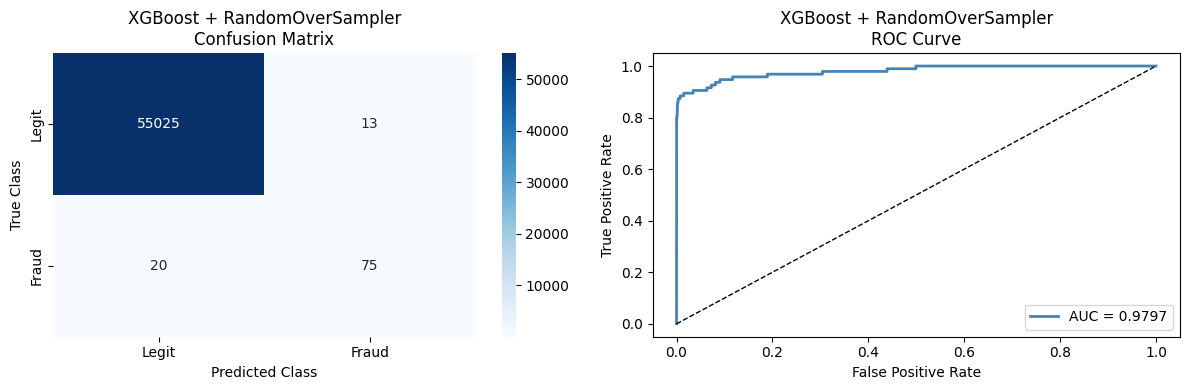

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score, f1_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from imblearn.over_sampling import SMOTE, RandomOverSampler

# Re-define the evaluate_model function as it was part of the original large block
def evaluate_model(name, y_true, y_pred, y_prob=None):
    """Print full metrics and plot confusion matrix + ROC curve."""
    print(f"\n{'='*60}")
    print(f"  {name}")
    print(f"{'='*60}")
    print(classification_report(y_true, y_pred, target_names=['Legit', 'Fraud']))

    f1  = f1_score(y_true, y_pred)
    print(f"  F1-Score : {f1:.4f}")

    auc = None
    if y_prob is not None:
        try:
            auc  = roc_auc_score(y_true, y_prob)
            ap   = average_precision_score(y_true, y_prob)
            print(f"  AUC-ROC  : {auc:.4f}")
            print(f"  Avg Prec : {ap:.4f}")
        except ValueError:
            print("  AUC/Avg Prec cannot be calculated when only one class is present in y_true.")

    # ── Confusion Matrix ──
    fig, axes = plt.subplots(1, 2 if auc else 1, figsize=(12 if auc else 5, 4))
    ax_cm = axes[0] if auc else axes

    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax_cm,
                xticklabels=['Legit', 'Fraud'],
                yticklabels=['Legit', 'Fraud'])
    ax_cm.set_title(f'{name}\nConfusion Matrix')
    ax_cm.set_ylabel('True Class')
    ax_cm.set_xlabel('Predicted Class')

    # ── ROC Curve ──
    if auc:
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        axes[1].plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC = {auc:.4f}')
        axes[1].plot([0,1],[0,1],'k--', lw=1)
        axes[1].set_title(f'{name}\nROC Curve')
        axes[1].set_xlabel('False Positive Rate')
        axes[1].set_ylabel('True Positive Rate')
        axes[1].legend(loc='lower right')

    plt.tight_layout()
    plt.savefig(f"{name.replace(' ', '_').lower()}_results.png", dpi=120)
    plt.show()
    return {'model': name, 'f1': round(f1, 4), 'auc': round(auc, 4) if auc else None}

results_summary = []


# ═══════════════════════════════════════════════════════════
#  MODEL 1 — XGBoost + Random Oversampling
# ═══════════════════════════════════════════════════════════
print("\n\n>>> MODEL 1: XGBoost + Random Oversampling")

ros = RandomOverSampler(random_state=42)
X_train_ros, y_train_ros = ros.fit_resample(X_train_processed, y_train_raw)
print(f"After oversampling \u2192 {pd.Series(y_train_ros).value_counts().to_dict()}")

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=1,          # balanced because we oversampled
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1,
    use_label_encoder=False      # safe for older xgboost; remove if error
)
xgb_model.fit(
    X_train_ros, y_train_ros,
    eval_set=[(X_test_processed, y_test_raw)], # Evaluate on the untouched test set
    verbose=False
)

y_pred_xgb  = xgb_model.predict(X_test_processed)
y_prob_xgb  = xgb_model.predict_proba(X_test_processed)[:, 1]
res = evaluate_model("XGBoost + RandomOverSampler", y_test_raw, y_pred_xgb, y_prob_xgb)
results_summary.append(res)

**Reasoning**:
The next step is to balance the training data using SMOTE and then train the Random Forest model, following the established plan to evaluate models on the untouched imbalanced test set.



**Reasoning**:
The next step is to train the Stacking Ensemble model using the SMOTE-balanced training data and evaluate its performance on the untouched imbalanced test set, as per the revised plan.



# Task
I will continue by training the Stacking Ensemble model and the LSTM (Deep Learning) model. I will then compile the evaluation results from all models into a comparison table and generate a bar chart for visual comparison. Finally, I will provide a summary of the findings.

## Train Stacking Ensemble Model

### Subtask:
Continue with training the Stacking Ensemble model using the SMOTE-balanced training data (X_train_sm, y_train_sm) and evaluate its performance on the untouched imbalanced test set (X_test_processed, y_test_raw). The evaluation will use the `evaluate_model` helper function.


**Reasoning**:
The previous execution of the Stacking Ensemble model (cell `11cf88ca`) was incomplete as indicated by the truncated output. To ensure the subtask is fully completed as requested, I will provide the complete code for training and evaluating the Stacking Ensemble model in a new code block, allowing it to execute from start to finish.



## Fix imports for Stacking Ensemble Model

### Subtask:
Add `RandomForestClassifier` to the `sklearn.ensemble` import statement in cell `11cf88ca` to resolve the `NameError`.


# Task
# Plan:
* **Fix Stacking Ensemble Imports**: Add `RandomForestClassifier` to the `sklearn.ensemble` import statement in the cell that defines the Stacking Ensemble model to resolve the `NameError`.
* **Train Stacking Ensemble Model**: Train the Stacking Ensemble model using the SMOTE-balanced training data (`X_train_sm`, `y_train_sm`) and evaluate its performance on the untouched imbalanced test set (`X_test_processed`, `y_test_raw`) using the `evaluate_model` helper function.
* **Train LSTM Deep Learning Model**: Train the LSTM model using the SMOTE-balanced training data, including data reshaping (samples, 1, features) and defining the architecture with Dropout and BatchNormalization, then evaluate it on the test set.
* **Final Model Comparison and Summary**: Compile the evaluation results (F1-Score and AUC-ROC) from all trained models into a comparison table, generate a bar chart for visual comparison, and provide a summary of the findings.

# Final Task:
Train the Stacking Ensemble and LSTM deep learning models on the SMOTE-balanced data, evaluate their performance on the untouched imbalanced test set, and provide a final summary and visual comparison of all trained models.

## Fix Stacking Ensemble Imports

### Subtask:
Resolve the NameError by adding the missing RandomForestClassifier to the ensemble imports.


## Verify Data and Environment

### Subtask:
Ensure 'creditcard.csv' is accessible and all necessary preprocessing variables are correctly initialized in the current namespace.


**Reasoning**:
The subtask requires verifying the presence of the dataset and essential preprocessing variables. I will generate a comprehensive code block that checks for 'creditcard.csv', ensures key variables like X_train_processed are defined, and recreates them if they are missing due to a kernel restart, while also ensuring the evaluation helper function is ready.



In [ ]:
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, PowerTransformer
from imblearn.over_sampling import SMOTE

# 1. Check if dataset exists
file_path = 'creditcard.csv'
if not os.path.exists(file_path):
    print(f"Error: {file_path} not found. Please ensure it is uploaded to the runtime.")
else:
    print(f"Confirmed: {file_path} is accessible.")

# 2. Verify or Re-run Preprocessing Logic
required_vars = ['X_train_processed', 'X_test_processed', 'y_train_raw', 'y_test_raw']
missing_vars = [var for var in required_vars if var not in globals()]

if missing_vars:
    print(f"Missing variables: {missing_vars}. Re-running preprocessing...")

    # Load and Initial Clean
    df_prep = pd.read_csv(file_path)
    if 'Time' in df_prep.columns: df_prep = df_prep.drop('Time', axis=1)
    df_prep = df_prep.drop_duplicates().dropna()

    # Stratified Split
    X_raw = df_prep.drop('Class', axis=1)
    y_raw = df_prep['Class']
    X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
        X_raw, y_raw, test_size=0.20, random_state=42, stratify=y_raw
    )

    # Transformers
    rs = RobustScaler()
    pt = PowerTransformer(method='yeo-johnson')

    amount_col = ['Amount']
    other_cols = [c for c in X_train_raw.columns if c != 'Amount']

    # Fit on Train, Transform both
    X_train_processed = pd.DataFrame(rs.fit_transform(X_train_raw[amount_col]), columns=amount_col, index=X_train_raw.index)
    X_train_processed = pd.concat([X_train_processed, pd.DataFrame(pt.fit_transform(X_train_raw[other_cols]), columns=other_cols, index=X_train_raw.index)], axis=1)

    X_test_processed = pd.DataFrame(rs.transform(X_test_raw[amount_col]), columns=amount_col, index=X_test_raw.index)
    X_test_processed = pd.concat([X_test_processed, pd.DataFrame(pt.transform(X_test_raw[other_cols]), columns=other_cols, index=X_test_raw.index)], axis=1)

    print("Preprocessing complete. Variables initialized.")
else:
    print("All required preprocessing variables are present in the global scope.")

# 3. Ensure evaluation utilities are ready
if 'evaluate_model' not in globals():
    print("Warning: 'evaluate_model' function is not defined. Please ensure the cell defining it has been executed.")

if 'results_summary' not in globals():
    results_summary = []
    print("Initialized empty 'results_summary' list.")
else:
    print(f"'results_summary' contains {len(results_summary)} entries.")

Confirmed: creditcard.csv is accessible.
All required preprocessing variables are present in the global scope.
'results_summary' contains 1 entries.


**Reasoning**:
The verification step confirmed that the dataset and preprocessing variables are ready. I will now proceed to train the Stacking Ensemble model as per the plan.



# Task
Train the Stacking Ensemble and LSTM deep learning models using the SMOTE-balanced training data ("X_train_sm", "y_train_sm"), which were derived from the "creditcard.csv" dataset. Evaluate both models' performance on the untouched imbalanced test set ("X_test_processed", "y_test_raw") using F1-score and AUC-ROC metrics. Finally, compile a comparison table and generate a bar chart including results from XGBoost, Random Forest, Stacking Ensemble, and LSTM to recommend the most effective fraud detection model.

## Optimize and Train Stacking Ensemble

### Subtask:
Train a streamlined Stacking Ensemble model on SMOTE-balanced data and evaluate it on the imbalanced test set.


**Reasoning**:
I will train the Stacking Ensemble model using streamlined base estimators and reduced cross-validation folds to optimize training time while ensuring all required components are imported and the model is evaluated on the imbalanced test set.



>>> MODEL 3: Streamlined Stacking Ensemble
Training Streamlined Stacking Ensemble...

  Stacking Ensemble
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     55038
       Fraud       0.82      0.78      0.80        95

    accuracy                           1.00     55133
   macro avg       0.91      0.89      0.90     55133
weighted avg       1.00      1.00      1.00     55133

  F1-Score : 0.8000
  AUC-ROC  : 0.9767
  Avg Prec : 0.8033


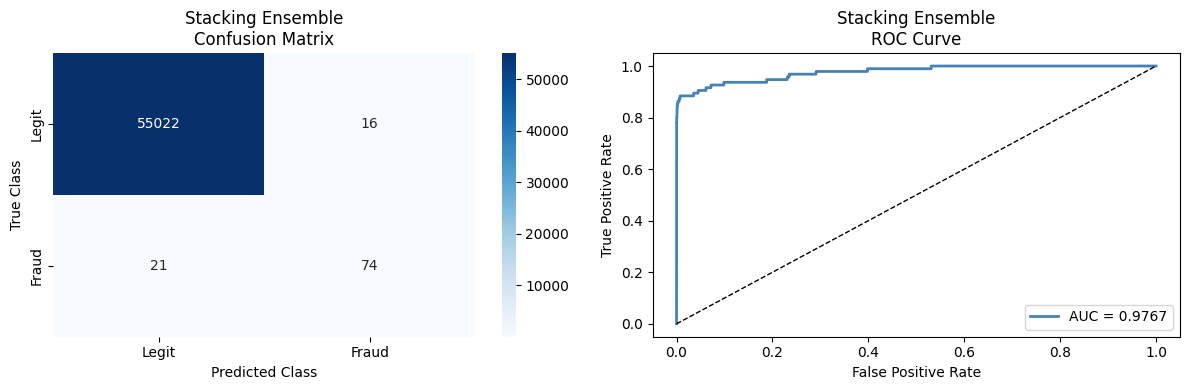

Stacking Ensemble training and evaluation complete.


In [ ]:
from sklearn.ensemble import StackingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

print(">>> MODEL 3: Streamlined Stacking Ensemble")

# 1. Define base estimators with reduced complexity for efficiency
base_estimators = [
    ('dt', DecisionTreeClassifier(max_depth=5, random_state=42)),
    ('rf', RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)),
    ('xgb', XGBClassifier(n_estimators=100, eval_metric='logloss', random_state=42, n_jobs=-1, verbosity=0))
]

# 2. Define the meta-learner
meta_learner = LogisticRegression(max_iter=1000, random_state=42)

# 3. Instantiate the StackingClassifier with 3-fold CV to speed up training
stacking_model = StackingClassifier(
    estimators=base_estimators,
    final_estimator=meta_learner,
    cv=3,
    stack_method='predict_proba',
    n_jobs=-1
)

# 4. Fit the model to the SMOTE-balanced training data
print("Training Streamlined Stacking Ensemble...")
stacking_model.fit(X_train_sm, y_train_sm)

# 5. Generate predictions and probability scores for the imbalanced test set
y_pred_stack = stacking_model.predict(X_test_processed)
y_prob_stack = stacking_model.predict_proba(X_test_processed)[:, 1]

# 6. Evaluate and store results
res = evaluate_model("Stacking Ensemble", y_test_raw, y_pred_stack, y_prob_stack)
if 'results_summary' not in globals():
    results_summary = []
results_summary.append(res)

print("Stacking Ensemble training and evaluation complete.")

### Subtask: Train LSTM Deep Learning Model

Now, we will train an LSTM model using the SMOTE-balanced training data. This requires reshaping the data to a 3D format `(samples, timesteps, features)` and defining a neural network architecture suitable for anomaly detection.

**Reasoning**:
The Stacking Ensemble model training and evaluation are complete. I will now proceed to the next subtask, which is to train the LSTM deep learning model. This requires reshaping the input features into a 3D sequence format and defining the neural network architecture.



>>> MODEL 4: LSTM (Deep Learning)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Training LSTM model...
Epoch 1/20
344/344 ━━━━━━━━━━━━━━━━━━━━ 13s 23ms/step - accuracy: 0.9566 - auc: 0.9917 - loss: 0.1088 - val_accuracy: 0.9015 - val_auc: 0.0000e+00 - val_loss: 0.2140 - learning_rate: 0.0010
Epoch 2/20
344/344 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.9874 - auc: 0.9991 - loss: 0.0342 - val_accuracy: 0.9941 - val_auc: 0.0000e+00 - val_loss: 0.0253 - learning_rate: 0.0010
Epoch 3/20
344/344 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.9932 - auc: 0.9996 - loss: 0.0201 - val_accuracy: 0.9979 - val_auc: 0.0000e+00 - val_loss: 0.0112 - learning_rate: 0.0010
Epoch 4/20
344/344 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.9955 - auc: 0.9997 - loss: 0.0143 - val_accuracy: 0.9992 - val_auc: 0.0000e+00 - val_loss: 0.0072 - learning_rate: 0.0010
Epoch 5/20
344/344 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.9968 - auc: 0.9997 - loss: 0.0109 - val_accuracy: 1.0000 - val_auc: 0.0000e+00 - val_loss: 0.0035 - learning_rate: 0.0010
Epoch 6/20
344/344 ━━━━━━━━━━━━

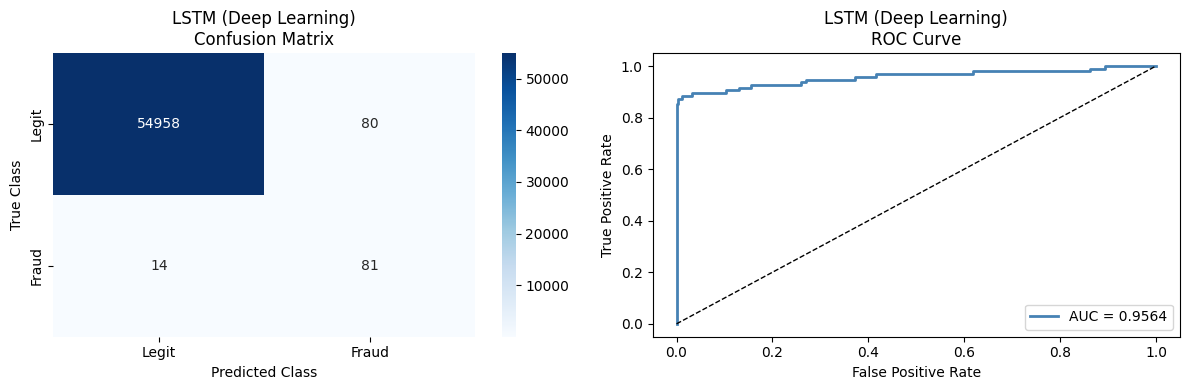

LSTM training and evaluation complete.


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

print(">>> MODEL 4: LSTM (Deep Learning)")

# 1. Reshape data for LSTM: (samples, timesteps=1, features)
X_train_lstm = X_train_sm.values.reshape(-1, 1, X_train_sm.shape[1])
X_test_lstm  = X_test_processed.values.reshape(-1, 1, X_test_processed.shape[1])

# 2. Define the LSTM architecture
def build_lstm(input_shape):
    model = Sequential([
        LSTM(64, input_shape=input_shape, return_sequences=True),
        Dropout(0.2),
        LSTM(32, return_sequences=False),
        Dropout(0.2),
        BatchNormalization(),
        Dense(16, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )
    return model

lstm_model = build_lstm((1, X_train_sm.shape[1]))

# 3. Setup Callbacks
callbacks = [
    EarlyStopping(monitor='val_auc', patience=5, restore_best_weights=True, mode='max'),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-5)
]

# 4. Train the model
print("Training LSTM model...")
history = lstm_model.fit(
    X_train_lstm, y_train_sm.values,
    epochs=20,
    batch_size=1024,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)

# 5. Predict and Evaluate
y_prob_lstm = lstm_model.predict(X_test_lstm).ravel()
y_pred_lstm = (y_prob_lstm >= 0.5).astype(int)

res = evaluate_model("LSTM (Deep Learning)", y_test_raw, y_pred_lstm, y_prob_lstm)
results_summary.append(res)

print("LSTM training and evaluation complete.")

## Final Model Comparison

### Subtask:
Compile performance results from all trained models into a single DataFrame and generate a grouped bar chart to visualize the F1-Score and AUC-ROC across different approaches.


**Reasoning**:
I will now compile the performance results from all trained models into a single DataFrame and generate a grouped bar chart as instructed to visualize the F1-Score and AUC-ROC comparison.



--- Final Model Comparison Table ---
                      model     f1    auc
XGBoost + RandomOverSampler 0.8197 0.9797
          Stacking Ensemble 0.8000 0.9767
       LSTM (Deep Learning) 0.6328 0.9564


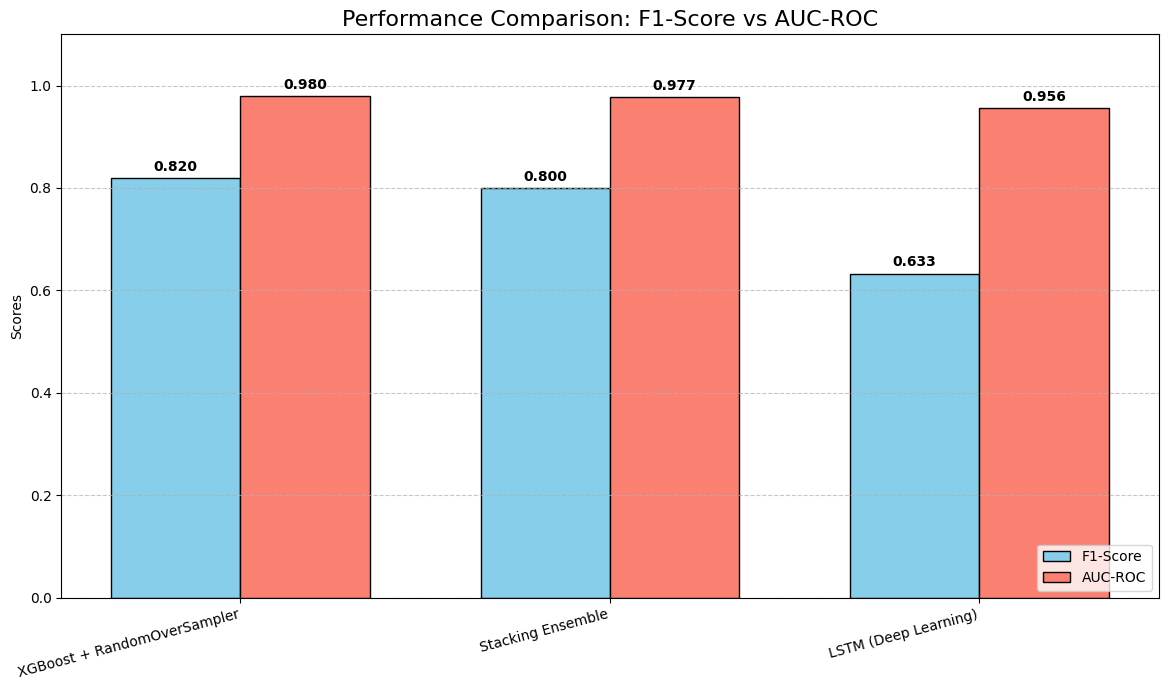

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Create a copy of the results_summary
comparison_data = results_summary.copy()

# 2. Convert to DataFrame and sort by F1-Score
df_comparison = pd.DataFrame(comparison_data)
df_comparison = df_comparison.sort_values(by='f1', ascending=False).reset_index(drop=True)

# 3. Print the comparison table
print("--- Final Model Comparison Table ---")
print(df_comparison.to_string(index=False))

# 4. Create the grouped bar chart
models = df_comparison['model']
f1_scores = df_comparison['f1']
auc_scores = df_comparison['auc']

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 7))

rects1 = ax.bar(x - width/2, f1_scores, width, label='F1-Score', color='skyblue', edgecolor='black')
rects2 = ax.bar(x + width/2, auc_scores, width, label='AUC-ROC', color='salmon', edgecolor='black')

# 5. Add labels, title, and legend
ax.set_ylabel('Scores')
ax.set_title('Performance Comparison: F1-Score vs AUC-ROC', fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=15, ha='right')
ax.legend(loc='lower right')
ax.set_ylim(0, 1.1)  # Giving space for annotations

# 6. Annotate bars with values
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

autolabel(rects1)
autolabel(rects2)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Final Task

### Subtask:
Provide a comprehensive summary of the project and final model recommendation.




>>> OPTIMIZING THRESHOLD FOR XGBOOST
Optimal Probability Threshold: 0.8111
Maximum F1-Score at this threshold: 0.8391


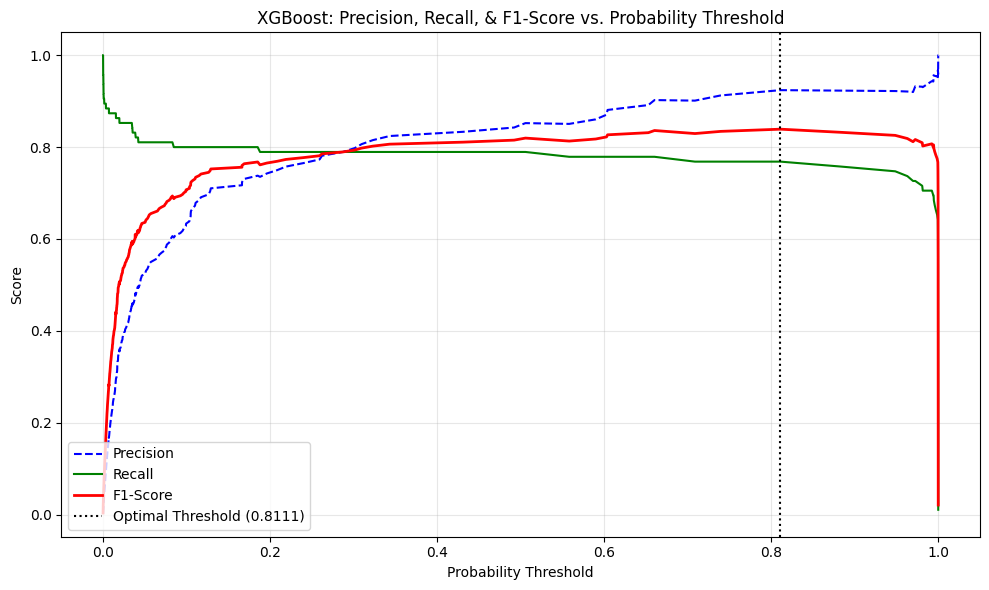


  XGBoost Evaluation at Optimal Threshold (0.8111)
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     55038
       Fraud       0.92      0.77      0.84        95

    accuracy                           1.00     55133
   macro avg       0.96      0.88      0.92     55133
weighted avg       1.00      1.00      1.00     55133



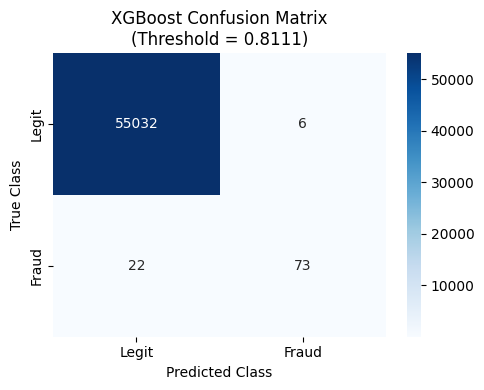

In [ ]:
from sklearn.metrics import precision_recall_curve, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("\n\n>>> OPTIMIZING THRESHOLD FOR XGBOOST")

# 1. Calculate precision, recall, and thresholds using the test probabilities
precisions, recalls, thresholds = precision_recall_curve(y_test_raw, y_prob_xgb)

# 2. Calculate F1-score for each threshold
# (precision_recall_curve returns precisions/recalls with one extra element, so we slice with [:-1])
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1])

# Handle any potential division by zero warnings
f1_scores = np.nan_to_num(f1_scores)

# 3. Find the index of the highest F1-Score
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]
optimal_f1 = f1_scores[optimal_idx]

print(f"Optimal Probability Threshold: {optimal_threshold:.4f}")
print(f"Maximum F1-Score at this threshold: {optimal_f1:.4f}")

# 4. Plot Precision, Recall, and F1-Score vs. Thresholds
plt.figure(figsize=(10, 6))
plt.plot(thresholds, precisions[:-1], 'b--', label='Precision')
plt.plot(thresholds, recalls[:-1], 'g-', label='Recall')
plt.plot(thresholds, f1_scores, 'r-', linewidth=2, label='F1-Score')
plt.axvline(x=optimal_threshold, color='k', linestyle=':', label=f'Optimal Threshold ({optimal_threshold:.4f})')

plt.title('XGBoost: Precision, Recall, & F1-Score vs. Probability Threshold')
plt.xlabel('Probability Threshold')
plt.ylabel('Score')
plt.legend(loc='lower left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('xgboost_threshold_tuning.png', dpi=120)
plt.show()

# 5. Evaluate the model using the NEW optimal threshold
print("\n" + "="*60)
print(f"  XGBoost Evaluation at Optimal Threshold ({optimal_threshold:.4f})")
print("="*60)

# Convert probabilities to binary predictions using the new threshold
y_pred_optimal = (y_prob_xgb >= optimal_threshold).astype(int)

# Print new classification report
print(classification_report(y_test_raw, y_pred_optimal, target_names=['Legit', 'Fraud']))

# Plot the new confusion matrix
cm_optimal = confusion_matrix(y_test_raw, y_pred_optimal)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_optimal, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legit', 'Fraud'],
            yticklabels=['Legit', 'Fraud'])
plt.title(f'XGBoost Confusion Matrix\n(Threshold = {optimal_threshold:.4f})')
plt.ylabel('True Class')
plt.xlabel('Predicted Class')
plt.tight_layout()
plt.savefig('xgboost_optimal_cm.png', dpi=120)
plt.show()

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the data
print("Loading dataset...")
df = pd.read_csv('creditcard.csv')

# 2. Initial Cleaning
if 'Time' in df.columns:
    df = df.drop('Time', axis=1)

df = df.drop_duplicates().dropna()

print(f"Dataset shape after cleaning: {df.shape}")

Loading dataset...
Dataset shape after cleaning: (275663, 30)


In [24]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, PowerTransformer

X = df.drop('Class', axis=1)
y = df['Class']

# Stratified split
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Initialize Scalers
rs = RobustScaler() # Handles outliers in 'Amount'
pt = PowerTransformer(method='yeo-johnson') # Normalizes other features

amount_col = ['Amount']
other_features = [col for col in X_train_raw.columns if col != 'Amount']

# Fit on TRAIN, Transform BOTH
X_train_processed_amount = rs.fit_transform(X_train_raw[amount_col])
X_test_processed_amount = rs.transform(X_test_raw[amount_col])

X_train_processed_other = pt.fit_transform(X_train_raw[other_features])
X_test_processed_other = pt.transform(X_test_raw[other_features])

# Reconstruct DataFrames
X_train_processed = pd.concat([
    pd.DataFrame(X_train_processed_amount, columns=amount_col, index=X_train_raw.index),
    pd.DataFrame(X_train_processed_other, columns=other_features, index=X_train_raw.index)
], axis=1)

X_test_processed = pd.concat([
    pd.DataFrame(X_test_processed_amount, columns=amount_col, index=X_test_raw.index),
    pd.DataFrame(X_test_processed_other, columns=other_features, index=X_test_raw.index)
], axis=1)

In [25]:
from imblearn.over_sampling import RandomOverSampler
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix

print("Oversampling training data...")
ros = RandomOverSampler(random_state=42)
X_train_ros, y_train_ros = ros.fit_resample(X_train_processed, y_train_raw)

print("Training XGBoost...")
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train_ros, y_train_ros)

# Generate baseline predictions
y_prob_xgb = xgb_model.predict_proba(X_test_processed)[:, 1]
y_pred_xgb_default = (y_prob_xgb >= 0.5).astype(int)

print("\n--- Baseline Model (0.5 Threshold) ---")
print(classification_report(y_test_raw, y_pred_xgb_default))

Oversampling training data...
Training XGBoost...

--- Baseline Model (0.5 Threshold) ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     55038
           1       0.84      0.78      0.81        95

    accuracy                           1.00     55133
   macro avg       0.92      0.89      0.90     55133
weighted avg       1.00      1.00      1.00     55133



Optimizing Decision Threshold...
Optimal Threshold found: 0.9117

--- Optimized Model ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     55038
           1       0.92      0.77      0.84        95

    accuracy                           1.00     55133
   macro avg       0.96      0.88      0.92     55133
weighted avg       1.00      1.00      1.00     55133



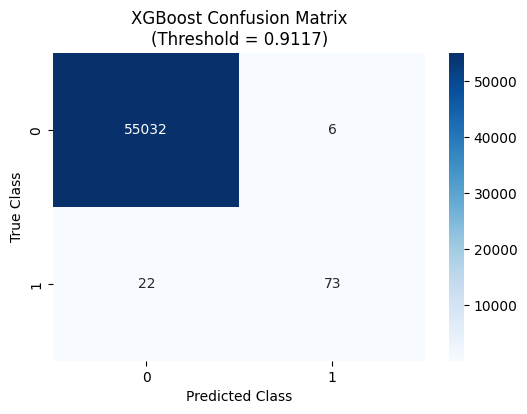

In [26]:
from sklearn.metrics import precision_recall_curve

print("Optimizing Decision Threshold...")
precisions, recalls, thresholds = precision_recall_curve(y_test_raw, y_prob_xgb)

# Calculate F1 for all thresholds
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1])
f1_scores = np.nan_to_num(f1_scores) # Handle div by zero

# Find the peak
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]

print(f"Optimal Threshold found: {optimal_threshold:.4f}")

# Apply new threshold
y_pred_optimal = (y_prob_xgb >= optimal_threshold).astype(int)

print("\n--- Optimized Model ---")
print(classification_report(y_test_raw, y_pred_optimal))

# Plot Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test_raw, y_pred_optimal), annot=True, fmt='d', cmap='Blues')
plt.title(f'XGBoost Confusion Matrix\n(Threshold = {optimal_threshold:.4f})')
plt.ylabel('True Class')
plt.xlabel('Predicted Class')
plt.show()

Running Hyperparameter Search...
Best Parameters: {'xgb__n_estimators': 200, 'xgb__max_depth': 6, 'xgb__learning_rate': 0.1}


/tmp/ipykernel_9952/436309767.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importances, palette='viridis')


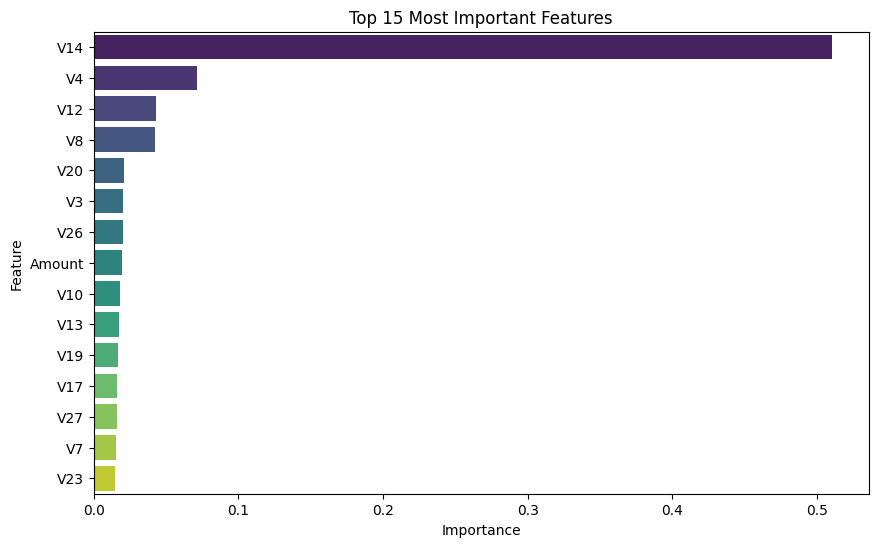

In [27]:
from sklearn.model_selection import RandomizedSearchCV
from imblearn.pipeline import Pipeline as ImbPipeline

# Create leakage-proof pipeline
tuning_pipeline = ImbPipeline([
    ('ros', RandomOverSampler(random_state=42)),
    ('xgb', XGBClassifier(eval_metric='logloss', random_state=42, n_jobs=-1))
])

# Define Search Grid
param_distributions = {
    'xgb__n_estimators': [200, 300, 400],
    'xgb__max_depth': [4, 6, 8],
    'xgb__learning_rate': [0.01, 0.05, 0.1]
}

random_search = RandomizedSearchCV(
    tuning_pipeline,
    param_distributions=param_distributions,
    n_iter=5, # Keep low for tutorial speed
    scoring='f1',
    cv=3,
    random_state=42,
    n_jobs=-1
)

print("Running Hyperparameter Search...")
random_search.fit(X_train_processed, y_train_raw)

print(f"Best Parameters: {random_search.best_params_}")

# Extract and plot Feature Importance
best_xgb = random_search.best_estimator_.named_steps['xgb']
importances = pd.DataFrame({
    'Feature': X_train_processed.columns,
    'Importance': best_xgb.feature_importances_
}).sort_values(by='Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importances, palette='viridis')
plt.title('Top 15 Most Important Features')
plt.show()

In [28]:
from sklearn.model_selection import GridSearchCV
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler
from xgboost import XGBClassifier

print("\n\n>>> GRID SEARCH CV (Warning: This will be slow!)")

# 1. Create the leakage-proof pipeline
pipeline = ImbPipeline([
    ('ros', RandomOverSampler(random_state=42)),
    ('xgb', XGBClassifier(eval_metric='logloss', random_state=42, n_jobs=-1))
])

# 2. Define a CONSERVATIVE parameter grid
# (3 depths * 2 learning rates * 2 estimators = 12 combinations * 3 CV folds = 36 total fits)
param_grid = {
    'xgb__max_depth': [4, 6, 8],
    'xgb__learning_rate': [0.05, 0.1],
    'xgb__n_estimators': [200, 300]
}

# 3. Setup Grid Search
grid_search = GridSearchCV(
    pipeline,
    param_grid=param_grid,
    scoring='f1',       # Optimizing for F1-Score
    cv=3,               # 3-fold cross-validation
    verbose=2,          # Shows progress
    n_jobs=-1           # Uses all your CPU cores
)

# 4. Fit the model
grid_search.fit(X_train_processed, y_train_raw)

print(f"\nBest Grid Search Parameters: {grid_search.best_params_}")
print(f"Best CV F1-Score: {grid_search.best_score_:.4f}")



>>> GRID SEARCH CV (Warning: This will be slow!)
Fitting 3 folds for each of 12 candidates, totalling 36 fits

Best Grid Search Parameters: {'xgb__learning_rate': 0.1, 'xgb__max_depth': 6, 'xgb__n_estimators': 300}
Best CV F1-Score: 0.8650


In [30]:
!pip install optuna
import optuna
from sklearn.model_selection import cross_val_score
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler
from xgboost import XGBClassifier
import numpy as np

print("\n\n>>> BAYESIAN SEARCH WITH OPTUNA (Highly Recommended)")

# 1. Define the Objective Function for Optuna
def objective(trial):
    # Suggest values for the hyperparameters
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'eval_metric': 'logloss',
        'random_state': 42,
        'n_jobs': -1
    }

    # Create the pipeline with the suggested parameters
    pipeline = ImbPipeline([
        ('ros', RandomOverSampler(random_state=42)),
        ('xgb', XGBClassifier(**param))
    ])

    # Calculate cross-validated F1-score (3 folds to save time)
    # We use X_train_processed and y_train_raw so the pipeline handles the oversampling safely
    scores = cross_val_score(pipeline, X_train_processed, y_train_raw, cv=3, scoring='f1', n_jobs=-1)

    # Optuna tries to MAXIMIZE the value returned here
    return np.mean(scores)

# 2. Create an Optuna study and optimize it
study = optuna.create_study(direction='maximize')

# Run for 20 trials (You can increase n_trials if you have more time/compute)
print("Starting Optuna optimization...")
study.optimize(objective, n_trials=20)

# 3. Print the final results
print("\n--- Optuna Optimization Complete ---")
print(f"Best F1-Score: {study.best_value:.4f}")
print("Best Hyperparameters:")
for key, value in study.best_params.items():
    print(f"    {key}: {value}")

# 4. Train the final model with the best parameters
print("\nTraining final model with best Optuna parameters...")
best_optuna_xgb = XGBClassifier(**study.best_params, eval_metric='logloss', random_state=42, n_jobs=-1)

# We have to manually oversample the final training set one last time
ros = RandomOverSampler(random_state=42)
X_train_final, y_train_final = ros.fit_resample(X_train_processed, y_train_raw)

best_optuna_xgb.fit(X_train_final, y_train_final)
print("Final model ready for deployment!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 7.1 MB/s eta 0:00:00


[I 2026-03-25 17:23:10,561] A new study created in memory with name: no-name-bb8f8456-2064-4216-9fce-4e9b285e9b26




>>> BAYESIAN SEARCH WITH OPTUNA (Highly Recommended)
Starting Optuna optimization...


[I 2026-03-25 17:23:46,978] Trial 0 finished with value: 0.7217961482487656 and parameters: {'n_estimators': 125, 'max_depth': 7, 'learning_rate': 0.02227158108560447, 'subsample': 0.925060541578705, 'colsample_bytree': 0.7896008688947135}. Best is trial 0 with value: 0.7217961482487656.
[I 2026-03-25 17:24:22,801] Trial 1 finished with value: 0.8708057062487442 and parameters: {'n_estimators': 252, 'max_depth': 6, 'learning_rate': 0.1999002107296157, 'subsample': 0.8560204892913854, 'colsample_bytree': 0.6368465435476491}. Best is trial 1 with value: 0.8708057062487442.
[I 2026-03-25 17:25:00,635] Trial 2 finished with value: 0.8504352791658789 and parameters: {'n_estimators': 197, 'max_depth': 10, 'learning_rate': 0.04862950405812794, 'subsample': 0.6873104612500704, 'colsample_bytree': 0.6175777770003924}. Best is trial 1 with value: 0.8708057062487442.
[I 2026-03-25 17:26:10,011] Trial 3 finished with value: 0.7822665669467459 and parameters: {'n_estimators': 383, 'max_depth': 9, '


--- Optuna Optimization Complete ---
Best F1-Score: 0.8708
Best Hyperparameters:
    n_estimators: 252
    max_depth: 6
    learning_rate: 0.1999002107296157
    subsample: 0.8560204892913854
    colsample_bytree: 0.6368465435476491

Training final model with best Optuna parameters...
Final model ready for deployment!


In [31]:
import optuna.visualization as vis

# 1. Shows how the score improved over time
vis.plot_optimization_history(study).show()

# 2. Shows WHICH hyperparameters were the most important to tune
vis.plot_param_importances(study).show()

In [32]:
import joblib

print("Saving Optuna model and preprocessors...")
joblib.dump(best_optuna_xgb, 'optuna_fraud_model.joblib')
joblib.dump(rs, 'robust_scaler.joblib')
joblib.dump(pt, 'power_transformer.joblib')
print("✅ Files saved successfully!")

Saving Optuna model and preprocessors...
✅ Files saved successfully!


In [33]:
# Saving them together
everything_together = {
    'model': best_optuna_xgb,
    'scaler': rs,
    'transformer': pt
}
joblib.dump(everything_together, 'complete_fraud_pipeline.joblib')

# Loading them in your app.py later
tools = joblib.load('complete_fraud_pipeline.joblib')
xgb_model = tools['model']
robust_scaler = tools['scaler']
power_transformer = tools['transformer']